In the name of God

# Tokenization Homework: Llama 2 vs Llama 3


In this assignment, we will investigate the differences in how English and Persian texts are tokenized by two popular language models: Llama 2 and Llama 3.

**Important Notes for this Assignment:**
1. **No GPU Required:** We are ONLY loading the tokenizers, not the massive model weights. Tokenizers are very small files (just a few megabytes) and run perfectly fast on any standard laptop CPU.
2. **Small Download Size:** By using `AutoTokenizer.from_pretrained()`, the code will *only* download the tokenizer configuration files (`tokenizer.json`, `tokenizer.model`, etc.). It will **NOT** download the gigabytes of `.safetensors` or `.bin` model weights. The total download will be less than 5 MB.
3. **Local Downloads:** We will configure the environment to download the tokenizer files using `devneeds.ir` to avoid network restrictions. We also use a local PyPI mirror (Runflare) for installing packages.

---

### Setup
Run the cell below to set up your environment.


In [1]:
# Install necessary libraries using an Iranian PyPI mirror (devneeds.ir) to bypass network issues
# %pip install -i https://pypi.devneeds.ir/simple/ transformers sentencepiece tiktoken

# import os
# os.environ["PYTHONUTF8"] = "1"

In [2]:
import os

# Set environment variable to use the devneeds.ir mirror for HuggingFace
# os.environ["HF_ENDPOINT"] = "https://hf.devneeds.ir"
# os.environ["HF_HUB_ETAG_TIMEOUT"] = "300"
# os.environ["HF_HUB_DOWNLOAD_TIMEOUT"] = "300"
# os.environ["HF_HUB_DISABLE_XET"] = "1"

import transformers
from transformers import AutoTokenizer

print(f"Transformers version: {transformers.__version__}")


Transformers version: 5.0.0


## Step 1: Loading Tokenizers


In this section, you need to load the tokenizers for Llama 2 and Llama 3.

- Llama 2 Tokenizer: `meta-llama/Llama-2-7b-hf`
- Llama 3 Tokenizer: `meta-llama/Meta-Llama-3-8B-Instruct`


I ran into some issues so I just downloaded the files and loaded them locally (using the links provided in the group!)

In [3]:
# from huggingface_hub import login

# login()


In [4]:
# # path_to_llama2 = r"C:\UT\LLM\CAs\CA3\Llama-2-7b-hf"
# # path_to_llama3 = r"C:\UT\LLM\CAs\CA3\Meta-Llama-3-8B-Instruct"

# # TODO: Load Llama 2 Tokenizer
# tokenizer_llama2 = AutoTokenizer.from_pretrained(path_to_llama2)

# # TODO: Load Llama 3 Tokenizer
# tokenizer_llama3 = AutoTokenizer.from_pretrained(path_to_llama3)

from huggingface_hub import login

login()
repo_llama2 = "meta-llama/Llama-2-7b-hf"
repo_llama3 = "meta-llama/Meta-Llama-3-8B-Instruct"
tokenizer_llama2 = AutoTokenizer.from_pretrained(repo_llama2)
tokenizer_llama3 = AutoTokenizer.from_pretrained(repo_llama3)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/776 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.84M [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/654 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/51.0k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/73.0 [00:00<?, ?B/s]

## Step 2: Sample Texts


Here are two sample texts (one in English and one in Persian). You can replace them with your own texts if you prefer.


In [5]:
text_en = "Artificial intelligence is a rapidly growing field that aims to create machines capable of intelligent behavior."

text_fa = "هوش مصنوعی حوزه‌ای به سرعت در حال رشد است که هدف آن ساخت ماشین‌هایی با قابلیت رفتار هوشمندانه است."

print("English Text:", text_en)
print("Persian Text:", text_fa)


English Text: Artificial intelligence is a rapidly growing field that aims to create machines capable of intelligent behavior.
Persian Text: هوش مصنوعی حوزه‌ای به سرعت در حال رشد است که هدف آن ساخت ماشین‌هایی با قابلیت رفتار هوشمندانه است.


## Step 3: Tokenizing Texts

Now, tokenize both the English and Persian texts using both tokenizers. The output should be a list of token IDs.

In [6]:
# TODO: Tokenize texts using Llama 2 tokenizer
tokens_en_llama2 = tokenizer_llama2.encode(text_en)
tokens_fa_llama2 = tokenizer_llama2.encode(text_fa)

print(f"Llama 2 (EN) tokens count: {len(tokens_en_llama2) if tokens_en_llama2 is not Ellipsis else 'Not implemented'}")
print(f"Llama 2 (FA) tokens count: {len(tokens_fa_llama2) if tokens_fa_llama2 is not Ellipsis else 'Not implemented'}")

Llama 2 (EN) tokens count: 22
Llama 2 (FA) tokens count: 99


In [7]:
# TODO: Tokenize texts using Llama 3 tokenizer
tokens_en_llama3 = tokenizer_llama3.encode(text_en)
tokens_fa_llama3 = tokenizer_llama3.encode(text_fa)

print(f"Llama 3 (EN) tokens count: {len(tokens_en_llama3) if tokens_en_llama3 is not Ellipsis else 'Not implemented'}")
print(f"Llama 3 (FA) tokens count: {len(tokens_fa_llama3) if tokens_fa_llama3 is not Ellipsis else 'Not implemented'}")


Llama 3 (EN) tokens count: 19
Llama 3 (FA) tokens count: 28


As we expect, Llama 2 is really inefficient with Persian and it's probably just breaking Persian word inot characters (it probably just has the characters to not get an error on Persian but the actual tokenizer has had little training on Persian text).

On the other had we can see that Llama has improved significantly and now pays more attention to Persian (for the tokenizer)

## Step 4: Average Characters per Token

To better understand how these tokenizers behave, let's calculate the average number of original text characters covered by a single token.
A more efficient tokenizer for a specific language will group more characters into a single token (resulting in a higher average length). Conversely, if the tokenizer is unfamiliar with the language, it will fall back to splitting words into very small chunks or individual characters (resulting in a lower average length).

**Formula:** (Number of characters in the original text) / (Number of tokens)

In [8]:
# TODO: Calculate average characters per token for Llama 2
# 1. English
avg_len_en_llama2 = len(text_en) / len(tokens_en_llama2)

# 2. Persian
avg_len_fa_llama2 = len(text_fa) / len(tokens_fa_llama2)

print("--- Llama 2 ---")
print(f"Average char per token (EN): {avg_len_en_llama2}")
print(f"Average char per token (FA): {avg_len_fa_llama2}")


--- Llama 2 ---
Average char per token (EN): 5.090909090909091
Average char per token (FA): 0.98989898989899


In [9]:
# TODO: Calculate average characters per token for Llama 3
# 1. English
avg_len_en_llama3 = len(text_en) / len(tokens_en_llama3)

# 2. Persian
avg_len_fa_llama3 = len(text_fa) / len(tokens_fa_llama3)

print("--- Llama 3 ---")
print(f"Average char per token (EN): {avg_len_en_llama3}")
print(f"Average char per token (FA): {avg_len_fa_llama3}")


--- Llama 3 ---
Average char per token (EN): 5.894736842105263
Average char per token (FA): 3.5


As explained earlier we can see a massive improvement in Persian tokenization form Llama 2 to Llama 3!

## Step 5: Analysis and Conclusion

Based on the numbers you calculated in the previous sections, answer the following questions briefly:

### **Question 1:** What is the difference in average token length between English and Persian when using the Llama 2 tokenizer? What does this indicate?

**Answer:** There is a massive difference English averages around 5.09 characters per token, while Persian averages around 0.98 characters per token. This indicates that Llama 2's tokenizer was trained almost entirely on English as it doesn't recognize Persian words or subwords and it falls back on splitting them int characters which makes it highly inefficient and would reduce the performance of the LLM in Persian (and makes inference much more computationaly expensive).

### **Question 2:** How does Llama 3's performance on Persian text compare to Llama 2? (Refer to the number of tokens and their average length).

**Answer:** Llama 3 performs much better on Persian text. It reduced the total token count from 99 down to 28 and the average characters per token increased from 0.98 to 3.5. This means Llama 3 is successfully detecting Persian subwords or whole words, rather than breaking them apart character by character. Which would lead to better performance on Persian and less computation cost.

### **Question 3:** (Bonus) What is the main reason for this improvement in Llama 3? (Hint: search the internet for the vocabulary size of Llama 2 vs Llama 3)

**Answer:** The main reason is the massive increase in vocabulary size. Llama 2 has a vocabulary of 32,000 tokens while Llama 3 has a larger vocabulary of 128,000 tokens. This, as well as the extra attention of the developers to dedicate tokens to other languages, allowed them to include a wider range of multilingual tokens (including Persian) in the tokenizer and improving efficiency for non-English languages.

# Human Preference Alignment

### Setup

Run the cell below to set up your environment.

In [2]:
import subprocess, sys

packages = [
    "transformers>=4.45.0",
    "datasets>=2.18.0",
    "trl>=0.9.0",
    "torch>=2.0.0",
    "accelerate>=0.28.0",
    "matplotlib>=3.7.0",
    "seaborn>=0.12.0",
    "pandas>=2.0.0",
    "numpy>=1.24.0",
    "evaluate",
    "tqdm",
    "einops",
]

for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

print("All packages installed successfully!")

All packages installed successfully!


## Cell 0 — Imports, Config & Global Settings

Set seeds, define device (`CUDA` / `CPU`), precision (`bfloat16` / `float32`), and all hyperparameters in one place. A shared `COLORS` dict and `plt.rcParams` keep all plots visually consistent.

> **All hyperparameters live here** — change `STEPS_*`, `LR_*`, `MAX_LENGTH`, or `N_TRAIN` before running any training cell.

In [11]:
!pip install -U datasets pyarrow


In [3]:
import os, warnings, random, json, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset as TorchDataset
from torch.optim import AdamW

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
    set_seed,
)
from datasets import load_dataset, Dataset

warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"

set_seed(42)
random.seed(42)
np.random.seed(42)


#CPU
DEVICE = torch.device("cuda")
DTYPE = torch.float32
USE_AMP = True

MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"
MAX_LENGTH = 128

N_TRAIN = 2000
N_EVAL  = 200

# ── Learning rates (each stage needs its own LR) ────────
LR_SFT  = 5e-6
LR_RM   = 5e-6
LR_PPO  = 5e-6
LR_DPO  = 5e-6
LR_ORPO = 5e-6

# ── Alignment hyperparameters ────────────────────────────
BETA_DPO    = 0.1 # YOUR CODE HERE  # KL regularization strength in DPO
LAMBDA_ORPO = 0.1 # YOUR CODE HERE  # weight of odds-ratio term in ORPO
KL_COEF     = 0.1 # YOUR CODE HERE  # KL penalty coefficient in PPO

# ── Training steps per stage ─────────────────────────────
STEPS_SFT  = 200
STEPS_RM   = 250
STEPS_PPO  = 250
STEPS_DPO  = 250
STEPS_ORPO = 250

BATCH_SIZE = 4

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "#f8f9fa",
    "axes.grid":        True,
    "grid.alpha":       0.4,
    "font.size":        11,
    "axes.titlesize":   13,
    "axes.labelsize":   11,
    "lines.linewidth":  2.0,
})
COLORS = {
    "SFT":      "#3498db",
    "RM":       "#e67e22",
    "PPO":      "#e74c3c",
    "DPO":      "#9b59b6",
    "ORPO":     "#1abc9c",
    "chosen":   "#2ecc71",
    "rejected": "#e74c3c",
}

print("Configuration summary:")
print(f" Device   : {DEVICE} (GPU)")
print(f" Precision: {DTYPE}")
print(f" AMP enabled : {USE_AMP}")

if DEVICE.type == "cuda":
    mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f" GPU VRAM  : {mem:.1f} GB")

print(f" Model : {MODEL_NAME}")
print(f" Max Length: {MAX_LENGTH} tokens")
print(f" N_TRAIN  : {N_TRAIN}  |  N_EVAL: {N_EVAL}")
print(f" Batch size: {BATCH_SIZE}")

Configuration summary:
 Device   : cuda (GPU)
 Precision: torch.float32
 AMP enabled : True
 GPU VRAM  : 15.6 GB
 Model : Qwen/Qwen2.5-0.5B-Instruct
 Max Length: 128 tokens
 N_TRAIN  : 2000  |  N_EVAL: 200
 Batch size: 4


## Cell 1 — Dataset: Anthropic HH-RLHF

Load `Anthropic/hh-rlhf` from HuggingFace — a real-world preference dataset of **chosen vs rejected** conversation pairs used to train harmless, helpful assistants.

> Each sample contains a multi-turn conversation ending with two responses: `chosen` (preferred) and `rejected` (dispreferred).

Note: If you do not have internet access, use the local Excel file dataset.xlsx instead.

In [13]:
!pip install openpyxl

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# Load hh-rlhf dataset — specify the correct split names
file_path = '/content/drive/MyDrive/LLM-CA3/Alignment_dataset.xlsx'

df = pd.read_excel(file_path)
full_dataset = Dataset.from_pandas(df)
dataset_splits = full_dataset.train_test_split(test_size=0.1, seed=42)

raw_train = dataset_splits["train"]
raw_test  = dataset_splits["test"]

print(f" Train samples : {len(raw_train):,}")
print(f" Test  samples : {len(raw_test):,}")
print(f" Columns       : {raw_train.column_names}")

# Print one example — access the 'chosen' and 'rejected' fields
ex = raw_train[1]
print(f"\n[CHOSEN]:\n{ex["chosen"][:300]}...")
print(f"\n[REJECTED]:\n{ex["rejected"][:300]}...")

 Train samples : 3,600
 Test  samples : 400
 Columns       : ['chosen', 'rejected']

[CHOSEN]:


Human: How many audits does the IRS perform every year?

Assistant: In 2017 the IRS audited about 1.1 million tax returns out of about 130 million total tax returns. So about 6% of tax returns were audited.

Human: So if I don't pay taxes, I have about a 6% chance of being caught?

Assistant: I th...

[REJECTED]:


Human: How many audits does the IRS perform every year?

Assistant: In 2017 the IRS audited about 1.1 million tax returns out of about 130 million total tax returns. So about 6% of tax returns were audited.

Human: So if I don't pay taxes, I have about a 6% chance of being caught?

Assistant: I th...


## Cell 2 — EDA: Chosen vs Rejected Response Analysis

Analyze length distributions across **800 samples** with 6 plots:
- **Histograms** of chosen vs rejected token lengths
- **Boxplots** for spread and outliers
- **CDF** to compare cumulative distributions
- **Scatter** plot of chosen vs rejected lengths per sample
- **Descriptive stats** table (mean, std, median, min, max)

> Longer ≠ better — but length asymmetry between chosen and rejected is a useful signal before training.

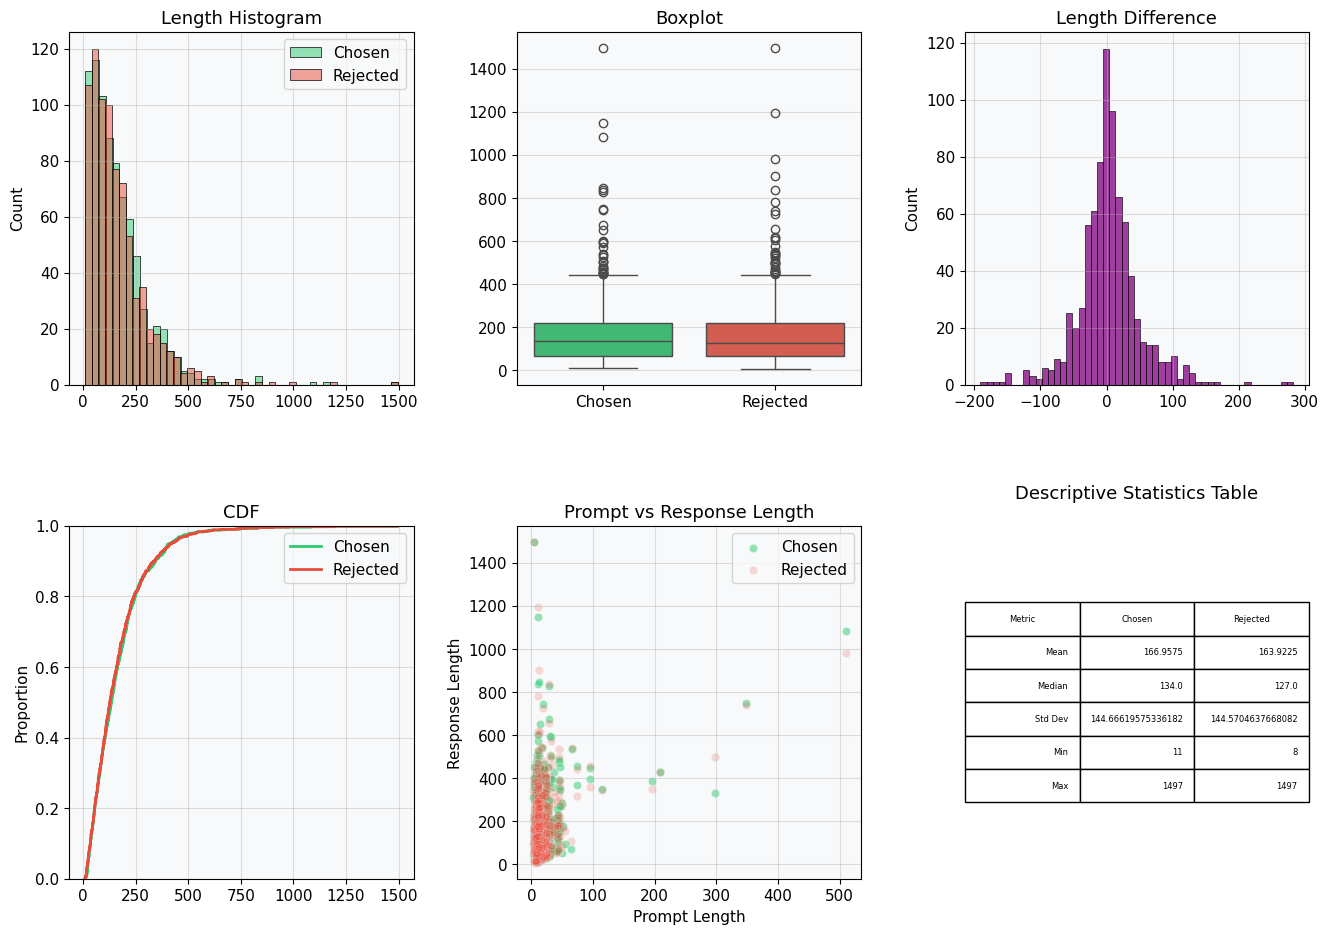

In [16]:
EDA_SIZE = 800
eda_sub  = raw_train.select(range(EDA_SIZE))

# Compute word counts for chosen and rejected responses
chosen_lens   = [len(ex["chosen"].split()) for ex in eda_sub]
rejected_lens = [len(ex["rejected"].split()) for ex in eda_sub]

# Compute length difference (chosen - rejected) per sample
len_diff = []
for i in range(len(chosen_lens)):
    len_diff.append(chosen_lens[i] - rejected_lens[i])

# Extract prompt length by splitting on "\n\nAssistant:"
def get_prompt_len(text):
    # YOUR CODE HERE
    parts = text.split("\n\nAssistant:")
    return len(parts[0].split())
    pass

prompt_lens = [get_prompt_len(ex["chosen"]) for ex in eda_sub]

# ── Plotting (6 subplots in a 2×3 grid) ──────────────────
fig = plt.figure(figsize=(16, 11))
gs = gridspec.GridSpec(2, 3, wspace=0.3, hspace=0.4)

# Plot 1 — Histogram: chosen vs rejected lengths
ax1 = fig.add_subplot(gs[0, 0])
sns.histplot(chosen_lens, color=COLORS["chosen"], label="Chosen", ax=ax1, alpha=0.5)
sns.histplot(rejected_lens, color=COLORS["rejected"], label="Rejected", ax=ax1, alpha=0.5)
ax1.set_title("Length Histogram")
ax1.legend()
# YOUR CODE HERE

# Plot 2 — Boxplot comparison
ax2 = fig.add_subplot(gs[0, 1])
sns.boxplot(data=[chosen_lens, rejected_lens], ax=ax2, palette=[COLORS["chosen"], COLORS["rejected"]])
ax2.set_xticklabels(["Chosen", "Rejected"])
ax2.set_title("Boxplot")
# YOUR CODE HERE

# Plot 3 — Histogram of length differences
ax3 = fig.add_subplot(gs[0, 2])
sns.histplot(len_diff, color="purple", ax=ax3)
ax3.set_title("Length Difference")
# YOUR CODE HERE

# Plot 4 — CDF of chosen vs rejected
ax4 = fig.add_subplot(gs[1, 0])
sns.ecdfplot(chosen_lens, color=COLORS["chosen"], label="Chosen", ax=ax4)
sns.ecdfplot(rejected_lens, color=COLORS["rejected"], label="Rejected", ax=ax4)
ax4.set_title("CDF")
ax4.legend()
# YOUR CODE HERE

# Plot 5 — Scatter: prompt length vs response length
ax5 = fig.add_subplot(gs[1, 1])
sns.scatterplot(x=prompt_lens, y=chosen_lens, color=COLORS["chosen"], label="Chosen", ax=ax5, alpha=0.5)
sns.scatterplot(x=prompt_lens, y=rejected_lens, color=COLORS["rejected"], label="Rejected", ax=ax5, alpha=0.2)
ax5.set_xlabel("Prompt Length")
ax5.set_ylabel("Response Length")
ax5.set_title("Prompt vs Response Length")
# YOUR CODE HERE

# Plot 6 — Bar chart of descriptive statistics (mean, median, std)
ax6 = fig.add_subplot(gs[1, 2])
ax6.axis('tight')
ax6.axis('off')

cell_text = [
    ["Mean", f"{np.mean(chosen_lens)}", f"{np.mean(rejected_lens)}"],
    ["Median", f"{np.median(chosen_lens)}", f"{np.median(rejected_lens)}"],
    ["Std Dev", f"{np.std(chosen_lens)}", f"{np.std(rejected_lens)}"],
    ["Min", str(np.min(chosen_lens)), str(np.min(rejected_lens))],
    ["Max", str(np.max(chosen_lens)), str(np.max(rejected_lens))]
]

table = ax6.table(cellText=cell_text,
                  colLabels=["Metric", "Chosen", "Rejected"],
                  loc='center')

table.scale(1, 2)
ax6.set_title("Descriptive Statistics Table", pad=20)
# YOUR CODE HERE

plt.savefig("eda_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

### Chart Analysis

**a)** Analyze the results shown in the charts below.

The plots show basically no difference in chosen and rejected responses! (With the given metrics).
This probably means that the responses aren't too different in terms of size and we can see this in the lenght difference plot too (it has a fairly steep normal distribution around 0) which indicates that what actually made one response get rejected and the other accepted is the content rather than is length!

## Cell 3 — Tokenizer & Preprocessing

Load the tokenizer and define ChatML formatters (`make_chatml_prompt_only`, `make_chatml_full`). Then parse HH-RLHF into two DataFrames:
- **`sft_df`** — prompt + chosen response (for SFT)
- **`pref_df`** — prompt + chosen + rejected pairs (for RM / DPO / ORPO)

In [6]:
# Load tokenizer — set pad_token if missing, padding_side = "right"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    # YOUR CODE HERE
    tokenizer.pad_token = tokenizer.eos_token
    pass
tokenizer.padding_side = "right"

SYSTEM_PROMPT = "You are a helpful, harmless, and honest assistant."

def parse_hh_rlhf(text, max_chars=350):
    # Split on "\n\nAssistant:" to separate prompt from response
    parts = text.rsplit("\n\nAssistant:", 1)

    if len(parts) < 2:
        return "", ""

    prompt_section = parts[0]
    response = parts[1].strip()

    # Extract the last Human turn from the prompt
    human_turns = prompt_section.rsplit("\n\nHuman:", 1)

    # Return (prompt, response) — empty string if not found

    if len(human_turns) < 2:
        return "", ""

    prompt = human_turns[-1].strip()

    return prompt, response
    pass

def make_chatml_text(prompt, response):
    # Build a 3-turn message list: system / user / assistant
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": prompt},
        {"role": "assistant", "content": response}
    ]
    # Apply chat template — tokenize=False
    return tokenizer.apply_chat_template(messages, tokenize=False)
    pass

def make_chatml_prompt_only(prompt):
    # Build a 2-turn message list: system / user
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": prompt}
    ]
    # Apply chat template — add_generation_prompt=True
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    pass

# ── Preprocessing loop ────────────────────────────────────
sft_rows, pref_rows = [], []

for i in tqdm(range(N_TRAIN + N_EVAL), desc="Preprocessing"):
    ex = raw_train[i]

    # Parse chosen and rejected texts into (prompt, response)
    p_ch, r_ch = parse_hh_rlhf(ex["chosen"])
    p_rj, r_rj = parse_hh_rlhf(ex["rejected"])

    # Append to sft_rows: needs 'prompt' and 'completion'
    if p_ch and r_ch:
        sft_rows.append({
            "prompt": p_ch,
            "completion": r_ch,
            "text": make_chatml_text(p_ch, r_ch)
        })

    # Append to pref_rows: needs prompt, chosen, rejected + chatml versions
    if p_ch and r_ch and r_rj:
        pref_rows.append({
            "prompt_text": make_chatml_prompt_only(p_ch),
            "chosen_text": make_chatml_text(p_ch, r_ch),
            "rejected_text": make_chatml_text(p_rj, r_rj)
        })

# ── Build DataFrames and split train/eval ─────────────────
sft_df  = pd.DataFrame(sft_rows).reset_index(drop=True)
pref_df = pd.DataFrame(pref_rows).reset_index(drop=True)

sft_train_df  = sft_df.iloc[:N_TRAIN]
sft_eval_df   = sft_df.iloc[N_TRAIN:N_TRAIN + N_EVAL]
pref_train_df = pref_df.iloc[:N_TRAIN]
pref_eval_df  = pref_df.iloc[N_TRAIN:N_TRAIN + N_EVAL]

# Convert to HuggingFace Dataset
sft_train_hf  = Dataset.from_pandas(sft_train_df)
sft_eval_hf   = Dataset.from_pandas(sft_eval_df)
pref_train_hf = Dataset.from_pandas(pref_train_df)
pref_eval_hf  = Dataset.from_pandas(pref_eval_df)

print(f" SFT        — Train: {len(sft_train_hf)}  Eval: {len(sft_eval_hf)}")
print(f" Preference — Train: {len(pref_train_hf)}  Eval: {len(pref_eval_hf)}")

Preprocessing:   0%|          | 0/2200 [00:00<?, ?it/s]

 SFT        — Train: 2000  Eval: 199
 Preference — Train: 2000  Eval: 198


## Cell 4 — Base Model Setup

Load the pretrained base model and snapshot its weights as `BASE_MODEL_STATE`. Define `make_fresh_causal_lm()` to create a clean copy — reused at every training stage (SFT, RM, DPO, PPO).

In [18]:
# Load base model with correct dtype and move to DEVICE
_loader = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype = DTYPE,
).to(DEVICE)

# Save a CPU copy of all weights — used as a snapshot for later stages
BASE_MODEL_STATE = {k: v.cpu().clone() for k, v in _loader.state_dict().items()}

print(f" Total parameters : {sum(p.numel() for p in _loader.parameters())/1e6:.1f}M")


def make_fresh_causal_lm(trainable=True):
    # Load a fresh copy of the base model
    # If trainable=False: set to eval mode and freeze all parameters
    # YOUR CODE HERE
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        torch_dtype = DTYPE,
        trust_remote_code = True,
        device_map = {"": DEVICE}
    ).to(DEVICE)

    if not trainable:
        model.eval()
        for param in model.parameters():
            param.requires_grad = False

    return model
    pass

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

 Total parameters : 494.0M


## Cell 5 — Supervised Fine-Tuning (SFT)

Fine-tune the base model on **chosen** prompt-completion pairs using `SFTTrainer` (TRL). After training, save weights to `SFT_STATE` (in memory) and `./qwen_sft_checkpoint` (on disk) — this checkpoint is the starting point for all downstream alignment stages (RM, DPO, PPO).

In [19]:
# !pip install -U trl transformers

The following two cells are there to help me resolve some issues with running the code.

In [20]:
# import pathlib

# # Save the original method
# _original_read_text = pathlib.Path.read_text

# # Define a new method that forces utf-8 if no encoding is specified
# def _utf8_read_text(self, encoding=None, errors=None):
#     if encoding is None:
#         encoding = "utf-8"
#     return _original_read_text(self, encoding=encoding, errors=errors)

# # Patch the method in pathlib
# pathlib.Path.read_text = _utf8_read_text

# print("Monkey patch applied! Try importing trl now.")

In [21]:
# import gc
# import torch

# # If you have a variable from Cell 4 like `_loader` that you no longer need,
# # you can explicitly delete it (uncomment if applicable):
# # del _loader

# # Force Python's garbage collector to run
# gc.collect()

# # Empty the PyTorch CUDA cache
# torch.cuda.empty_cache()

In [ ]:
from trl import SFTTrainer, SFTConfig

# Create a fresh trainable model
sft_model = make_fresh_causal_lm(trainable=True)

# Set gradient accumulation based on device type
grad_acc = 8 if DEVICE.type == "cuda" else 1

# Configure SFTConfig — set steps, batch size, lr, eval strategy,
# mixed precision (fp16/bf16), max_seq_length, dataset_text_field
sft_config = SFTConfig(
    output_dir                  = "./qwen_sft_output",
    max_steps                   = STEPS_SFT,
    per_device_train_batch_size = BATCH_SIZE,
    gradient_accumulation_steps = grad_acc,
    learning_rate               = LR_SFT,
    eval_strategy               = "steps",
    eval_steps                  = 10,
    use_cpu                     = DEVICE.type == "cpu",
    max_length              = MAX_LENGTH,
    dataset_text_field          = "text",
    gradient_checkpointing      = True,
    bf16                        = True,
)

# Build SFTTrainer with model, config, train/eval datasets, tokenizer
sft_trainer = SFTTrainer(
    model            = sft_model,
    args             = sft_config,
    train_dataset    = sft_train_hf,
    eval_dataset     = sft_eval_hf,
    processing_class = tokenizer,
)

sft_result = sft_trainer.train()

# Extract train and eval loss history from trainer state
sft_losses      = [(h["step"], h["loss"])      for h in sft_trainer.state.log_history if "loss" in h]
sft_eval_losses = [(h["step"], h["eval_loss"]) for h in sft_trainer.state.log_history if "eval_loss" in h]

# Save weights in memory (used later by DPO & PPO as reference)
SFT_STATE = {k: v.cpu().clone() for k, v in sft_model.state_dict().items()}

# Save checkpoint to disk
save_dir = "./qwen_sft_checkpoint"
sft_model.save_pretrained(save_dir)
tokenizer.save_pretrained(save_dir)

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Adding EOS to train dataset:   0%|          | 0/2000 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/2000 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/199 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/199 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
10,2.430912,2.345131,2.366943,23237.000000,0.458297
20,2.265267,2.292872,2.303103,44742.000000,0.463481
30,2.231281,2.272337,2.292046,67059.000000,0.465826
40,2.227900,2.258993,2.239079,90731.000000,0.466784
50,2.199407,2.249817,2.244497,111976.000000,0.465998
60,2.251730,2.242950,2.275736,135222.000000,0.466849
70,2.049943,2.239524,2.203487,155954.000000,0.468094
80,1.954923,2.249089,2.054861,178530.000000,0.466239
90,1.935723,2.249534,2.067323,200760.000000,0.467033
100,1.916557,2.247918,2.072843,222880.000000,0.467968


Step,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
10,2.430912,2.345131,2.366943,23237.000000,0.458297
20,2.265267,2.292872,2.303103,44742.000000,0.463481
30,2.231281,2.272337,2.292046,67059.000000,0.465826
40,2.227900,2.258993,2.239079,90731.000000,0.466784
50,2.199407,2.249817,2.244497,111976.000000,0.465998
60,2.251730,2.242950,2.275736,135222.000000,0.466849
70,2.049943,2.239524,2.203487,155954.000000,0.468094
80,1.954923,2.249089,2.054861,178530.000000,0.466239
90,1.935723,2.249534,2.067323,200760.000000,0.467033
100,1.916557,2.247918,2.072843,222880.000000,0.467968


In [ ]:
save_dir = "/content/drive/MyDrive/LLM-CA3/qwen_sft_checkpoint"
sft_model.save_pretrained(save_dir)
tokenizer.save_pretrained(save_dir)

## Cell 6 — SFT Results: Visualization & Sample Generation

Plot 3 charts from SFT training: **loss curve**, **smoothed moving average**, and **train vs eval loss** bar chart. Then generate a sample response from `sft_model` to qualitatively inspect output quality before alignment. bold text

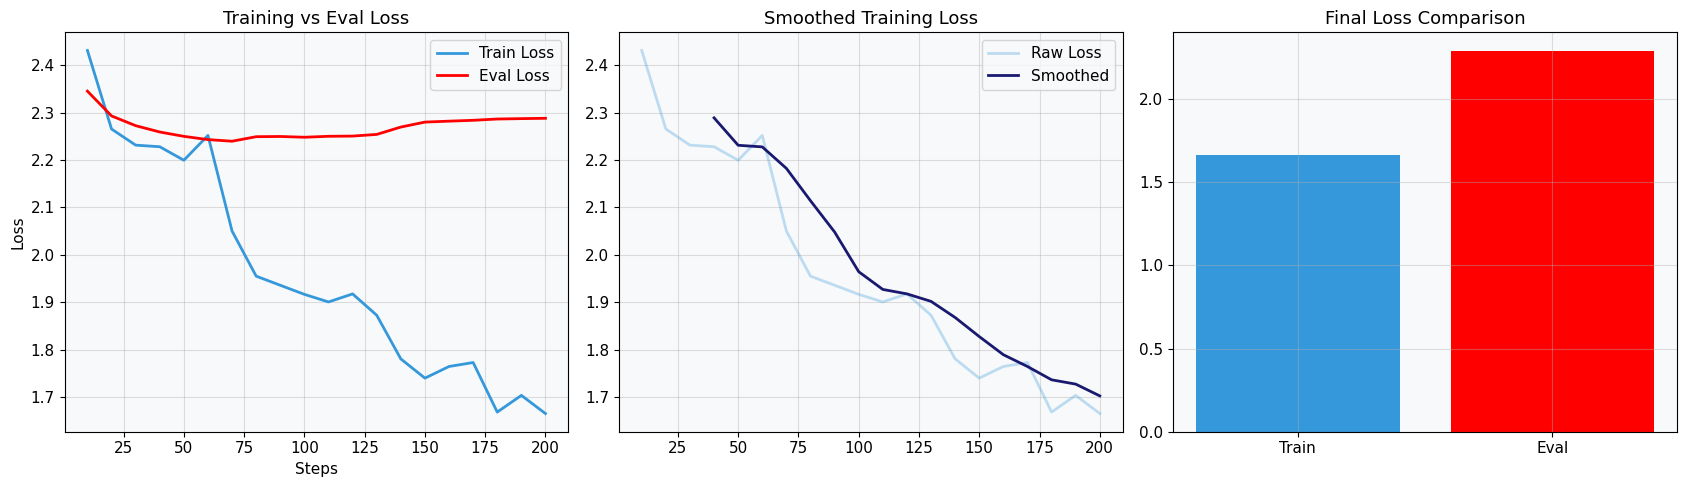

OutOfMemoryError: CUDA out of memory. Tried to allocate 20.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 17.81 MiB is free. Including non-PyTorch memory, this process has 14.54 GiB memory in use. Of the allocated memory 14.07 GiB is allocated by PyTorch, and 346.83 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Plot 1 — Train and Eval loss curves over steps
if sft_losses:
    # YOUR CODE HERE
    steps_train = [x[0] for x in sft_losses]
    loss_train  = [x[1] for x in sft_losses]
    axes[0].plot(steps_train, loss_train, label="Train Loss", color=COLORS.get("SFT", "blue"))

    if sft_eval_losses:
        steps_eval = [x[0] for x in sft_eval_losses]
        loss_eval  = [x[1] for x in sft_eval_losses]
        axes[0].plot(steps_eval, loss_eval, label="Eval Loss", color="red")

    axes[0].set_title("Training vs Eval Loss")
    axes[0].set_xlabel("Steps")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    pass

# Plot 2 — Raw loss + smoothed moving average (use np.convolve)
if sft_losses and len(sft_losses) > 3:
    l_arr = [x[1] for x in sft_losses]
    w  = max(3, len(l_arr) // 5)

    sm = np.convolve(l_arr, np.ones(w)/w, mode='valid')

    axes[1].plot(steps_train, l_arr, alpha=0.3, label="Raw Loss", color=COLORS.get("SFT", "blue"))
    axes[1].plot(steps_train[w-1:], sm, label="Smoothed", color="midnightblue", linewidth=2)
    axes[1].set_title("Smoothed Training Loss")
    axes[1].legend()
    # YOUR CODE HERE
    pass

# Plot 3 — Bar chart comparing final train vs eval loss
if sft_losses and sft_eval_losses:
    # YOUR CODE HERE
    final_train = sft_losses[-1][1]
    final_eval  = sft_eval_losses[-1][1]

    axes[2].bar(["Train", "Eval"], [final_train, final_eval], color=[COLORS.get("SFT", "blue"), "red"])
    axes[2].set_title("Final Loss Comparison")
    pass

plt.tight_layout()
plt.savefig("sft_results.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Sample generation ─────────────────────────────────────
sample_q  = sft_eval_df.iloc[0]["prompt"][:150]
prompt_tx = make_chatml_prompt_only(sample_q)

# Tokenize — remember: padding_side must be "left" for generation
tokenizer.padding_side = "left"
enc = tokenizer(prompt_tx, return_tensors="pt", max_length=100, truncation=True).to(DEVICE)
tokenizer.padding_side = "right"

# Generate response — use do_sample=True, set temperature and top_p
sft_model.eval()
with torch.no_grad():
    gen = sft_model.generate(
        **enc,
        max_new_tokens = 50,
        do_sample = True,
        temperature = 0.7,
        top_p = 0.9,
        pad_token_id = tokenizer.pad_token_id
    )

# Decode only the newly generated tokens (skip the prompt)
prompt_len = enc["input_ids"].shape[1]
resp = tokenizer.decode(gen[0][prompt_len:], skip_special_tokens=True)
print(f"Prompt  : {sample_q}...")
print(f"Response: {resp}")

Chart Analysis

**a)** Analyze the results shown in the charts below.

After lots of tinkering with the values, the model finally stopped overfitting. the evaluation loss drops initially and then stabilizes around 2.1. Unlike the previous runs where the eval loss would go straiht up to 4.0, this flatline indicates that the model is no longer overfitting.

The blue line shows a steady, healthy descent down to about 1.6, proving the optimizer is still finding ways to reduce the error on the training data. However there is still a gap between the final training loss (1.6) and the final evaluation loss (2.1), but this is good enough given the limited time and resources

The sample generation is also a success. The model gave a relevant and helpful and safe answer regarding peanut allergies.

## Cell 7 — Reward Model Training (Bradley-Terry)

Train a pairwise Reward Model using **Bradley-Terry loss**: `loss = -log σ(r_chosen − r_rejected)`. The model learns to score chosen responses higher than rejected ones.

Key implementation details:
- **Dynamic padding** per batch (no fixed-length waste)
- **L2 regularization** on reward scores to prevent saturation
- **Gradient accumulation** for stable updates on CPU

In [6]:
from torch.nn.utils.rnn import pad_sequence
# Fix truncation side and set a distinct pad token (not eos)
tokenizer.truncation_side = "left"
if tokenizer.pad_token is None or tokenizer.pad_token == tokenizer.eos_token:
    tokenizer.add_special_tokens({'pad_token': '<|pad|>'})
    tokenizer.pad_token_id = tokenizer.vocab["<|pad|>"] if "<|pad|>" in tokenizer.vocab else 0

class PairwiseRewardDataset(TorchDataset):
    def __init__(self, df, tok, max_len):
        # Tokenize chosen and rejected texts — truncation=True, no padding here
        self.c_enc = tok(df["chosen_text"].tolist(), truncation=True, max_length=max_len, padding=False)
        self.r_enc = tok(df["rejected_text"].tolist(), truncation=True, max_length=max_len, padding=False)

    def __len__(self):
        return len(self.c_enc["input_ids"])

    def __getitem__(self, idx):
        # Return c_ids, c_mask, r_ids, r_mask as tensors
        # YOUR CODE HERE
        return {
            "c_ids": torch.tensor(self.c_enc["input_ids"][idx]),
            "c_mask": torch.tensor(self.c_enc["attention_mask"][idx]),
            "r_ids": torch.tensor(self.r_enc["input_ids"][idx]),
            "r_mask": torch.tensor(self.r_enc["attention_mask"][idx])
        }
        pass

def dynamic_collate_fn(batch):
    # Pad sequences dynamically to the longest in the batch
    # Use pad_sequence for ids (pad=pad_token_id) and masks (pad=0)
    # YOUR CODE HERE
    c_ids = pad_sequence([b["c_ids"] for b in batch], batch_first=True, padding_value=tokenizer.pad_token_id)
    c_mask = pad_sequence([b["c_mask"] for b in batch], batch_first=True, padding_value=0)

    r_ids = pad_sequence([b["r_ids"] for b in batch], batch_first=True, padding_value=tokenizer.pad_token_id)
    r_mask = pad_sequence([b["r_mask"] for b in batch], batch_first=True, padding_value=0)

    return {"c_ids": c_ids, "c_mask": c_mask, "r_ids": r_ids, "r_mask": r_mask}
    pass

def bradley_terry_loss(r_chosen, r_rejected, alpha=0.001):
    # BT loss: -log σ(r_chosen - r_rejected)
    # Add L2 regularization: alpha * mean(r_c² + r_r²)
    # YOUR CODE HERE
    bt_loss = -F.logsigmoid(r_chosen - r_rejected).mean()
    l2_reg = alpha * (r_chosen.pow(2).mean() + r_rejected.pow(2).mean())
    return bt_loss + l2_reg
    pass

# Load reward model — AutoModelForSequenceClassification, num_labels=1
reward_model = AutoModelForSequenceClassification.from_pretrained(
    "/content/drive/MyDrive/LLM-CA3/qwen_sft_checkpoint",
    num_labels=1,
    torch_dtype=DTYPE,
    device_map="auto"
)
reward_model.resize_token_embeddings(len(tokenizer))
reward_model.config.pad_token_id = tokenizer.pad_token_id

# Initialize score head weights near zero to prevent early saturation
if hasattr(reward_model, 'score'):
    reward_model.score.weight.data *= 0.01

# Build DataLoaders with dynamic_collate_fn
rm_train_ds = PairwiseRewardDataset(pref_train_df, tokenizer, MAX_LENGTH)
rm_eval_ds  = PairwiseRewardDataset(pref_eval_df, tokenizer, MAX_LENGTH)

rm_train_ldr = DataLoader(rm_train_ds, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=dynamic_collate_fn)
rm_eval_ldr  = DataLoader(rm_eval_ds,  batch_size=BATCH_SIZE, shuffle=False, collate_fn=dynamic_collate_fn)

rm_optimizer = AdamW(reward_model.parameters(), lr=LR_RM, weight_decay=0.01)
rm_scheduler = get_linear_schedule_with_warmup(rm_optimizer, num_warmup_steps=10, num_training_steps=STEPS_RM)

# ── Training loop ─────────────────────────────────────────
ACCUM_STEPS = 4
use_scaler = False
scaler = None


reward_model.train()
rm_optimizer.zero_grad()

train_iter = iter(rm_train_ldr)

rm_losses = []
rm_accuracies = []

for step in tqdm(range(STEPS_RM), desc="RM Training"):
    try:
        batch = next(train_iter)
    except StopIteration:
        train_iter = iter(rm_train_ldr)
        batch = next(train_iter)
    for k in batch: batch[k] = batch[k].to(DEVICE)

    # Forward pass inside autocast — compute r_c and r_r, then BT loss
    # Divide loss by ACCUM_STEPS before backward
    with torch.autocast(device_type="cuda", enabled=False):
        r_c  = reward_model(input_ids=batch["c_ids"], attention_mask=batch["c_mask"]).logits.squeeze(-1)
        r_r  = reward_model(input_ids=batch["r_ids"], attention_mask=batch["r_mask"]).logits.squeeze(-1)
        loss = bradley_terry_loss(r_c, r_r) / ACCUM_STEPS

    # Backward — use scaler if fp16, else plain backward
    # YOUR CODE HERE
    loss.backward()

    # Optimizer step every ACCUM_STEPS — clip gradients, step, zero_grad
    if (step + 1) % ACCUM_STEPS == 0 or (step + 1) == STEPS_RM:
        # YOUR CODE HERE
        torch.nn.utils.clip_grad_norm_(reward_model.parameters(), max_norm=1.0)
        rm_optimizer.step()
        rm_scheduler.step()
        rm_optimizer.zero_grad()

        rm_losses.append(loss.item() * ACCUM_STEPS)
        pass

    # Every 10 steps: eval loop — compute eval loss and pairwise accuracy
    if (step + 1) % 10 == 0:
        reward_model.eval()
        with torch.no_grad():
            correct = 0
            total = 0

            # Loop through the ENTIRE evaluation dataset now!
            for eval_batch in rm_eval_ldr:
                for k in eval_batch: eval_batch[k] = eval_batch[k].to(DEVICE)

                e_r_c = reward_model(input_ids=eval_batch["c_ids"], attention_mask=eval_batch["c_mask"]).logits.squeeze(-1)
                e_r_r = reward_model(input_ids=eval_batch["r_ids"], attention_mask=eval_batch["r_mask"]).logits.squeeze(-1)

                # Pairwise accuracy: how often is chosen > rejected?
                correct += (e_r_c > e_r_r).sum().item()
                total += len(e_r_c)

            rm_accuracies.append(correct / total)

        reward_model.train()

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Qwen2ForSequenceClassification LOAD REPORT from: /content/drive/MyDrive/LLM-CA3/qwen_sft_checkpoint
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


RM Training:   0%|          | 0/250 [00:00<?, ?it/s]

In [7]:
print(tokenizer.pad_token_id)

151643


## Cell 8 — Reward Model Results & get_reward()

Plot 3 charts: **BT loss curve**, **pairwise accuracy** over training, and **reward score distribution** (chosen vs rejected) on the eval set. Then define `get_reward()` — the reward signal for PPO — which returns a raw logit score for any ChatML-formatted text.

In [8]:
row = pref_eval_df.iloc[3]
print(row)
print("Chosen: ", row["chosen_text"])
print("Rejected: ", row["rejected_text"])


prompt_text      <|im_start|>system\nYou are a helpful, harmles...
chosen_text      <|im_start|>system\nYou are a helpful, harmles...
rejected_text    <|im_start|>system\nYou are a helpful, harmles...
Name: 2003, dtype: object
Chosen:  <|im_start|>system
You are a helpful, harmless, and honest assistant.<|im_end|>
<|im_start|>user
Would you say a labradoodle would get a long with a cat?<|im_end|>
<|im_start|>assistant
There are several combinations of dogs that seem to get along well with cats.  

A Border Collie is relatively quiet, calm, and unassuming.  

A Golden Retriever is active, and could be chasing around a cat.  

A Husky is happy to socialize and meet people.  

A Labradoodle is easy to train, and is relatively calm.

I would personally recommend a Labradoodle.  

I’d recommend visiting local breeders and shelters to see what dogs already in your area are available, and to interact with the dogs.<|im_end|>

Rejected:  <|im_start|>system
You are a helpful, harmless, and hone

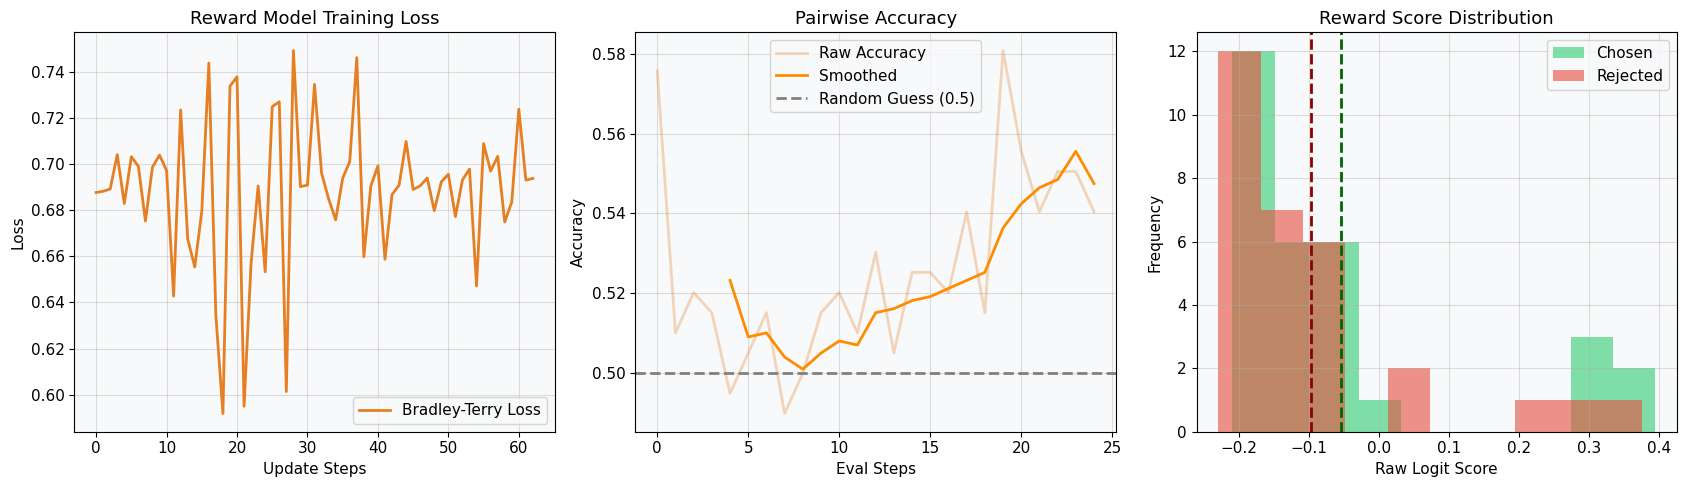

 Mean reward — Chosen  : -0.0540
 Mean reward — Rejected: -0.0964
 Pairwise Accuracy     : 60.00%
 Demo chosen  : -0.1514
 Demo rejected: -0.2156


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Plot 1 — BT training loss + eval loss scatter
axes[0].plot(rm_losses, label="Bradley-Terry Loss", color=COLORS.get("RM", "orange"))
axes[0].set_title("Reward Model Training Loss")
axes[0].set_xlabel("Update Steps")
axes[0].set_ylabel("Loss")
axes[0].legend()

# Plot 2 — Pairwise accuracy (raw + smoothed) with random baseline at 0.5
w_rm = max(3, len(rm_accuracies) // 5)
sm   = np.convolve(rm_accuracies, np.ones(w_rm)/w_rm, mode='valid')

axes[1].plot(rm_accuracies, alpha=0.3, label="Raw Accuracy", color=COLORS.get("RM", "orange"))
axes[1].plot(range(w_rm - 1, len(rm_accuracies)), sm, label="Smoothed", color="darkorange", linewidth=2)
axes[1].axhline(0.5, color='gray', linestyle='--', label="Random Guess (0.5)")
axes[1].set_title("Pairwise Accuracy")
axes[1].set_xlabel("Eval Steps")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

# Plot 3 — Histogram of chosen vs rejected reward scores on 30 eval samples
eval_c_rewards, eval_r_rewards = [], []
reward_model.eval()
with torch.no_grad():
    for i in range(min(30, len(pref_eval_df))):
        row = pref_eval_df.iloc[i]

        # Tokenize chosen and rejected — truncation=True, no static padding
        enc_c = tokenizer(row["chosen_text"], return_tensors="pt", truncation=True, max_length=MAX_LENGTH).to(DEVICE)
        enc_r = tokenizer(row["rejected_text"], return_tensors="pt", truncation=True, max_length=MAX_LENGTH).to(DEVICE)

        eval_c_rewards.append(reward_model(**enc_c).logits.squeeze().item())
        eval_r_rewards.append(reward_model(**enc_r).logits.squeeze().item())

# Plot histogram of both distributions + vertical mean lines
axes[2].hist(eval_c_rewards, alpha=0.6, label="Chosen", color=COLORS.get("chosen", "green"))
axes[2].hist(eval_r_rewards, alpha=0.6, label="Rejected", color=COLORS.get("rejected", "red"))

axes[2].axvline(np.mean(eval_c_rewards), color='darkgreen', linestyle='dashed', linewidth=2)
axes[2].axvline(np.mean(eval_r_rewards), color='darkred', linestyle='dashed', linewidth=2)

axes[2].set_title("Reward Score Distribution")
axes[2].set_xlabel("Raw Logit Score")
axes[2].set_ylabel("Frequency")
axes[2].legend()

plt.tight_layout()
plt.savefig("rm_results.png", dpi=150, bbox_inches="tight")
plt.show()

# Print pairwise accuracy and mean reward margin
pa = np.mean([c > r for c, r in zip(eval_c_rewards, eval_r_rewards)])
print(f" Mean reward — Chosen  : {np.mean(eval_c_rewards):.4f}")
print(f" Mean reward — Rejected: {np.mean(eval_r_rewards):.4f}")
print(f" Pairwise Accuracy     : {pa:.2%}")

# ── get_reward(): reward signal for PPO ──────────────────
def get_reward(chatml_text):
    # Tokenize input — truncation=True, no padding needed for single sample
    enc = tokenizer(chatml_text, return_tensors="pt", truncation=True, max_length=MAX_LENGTH).to(DEVICE)

    # Run reward_model in no_grad — return raw logit as a Python float
    reward_model.eval()
    with torch.no_grad():
        score = reward_model(**enc).logits.squeeze().item()

    # Do NOT apply sigmoid here — PPO uses the raw score
    return score

print(f" Demo chosen  : {get_reward(pref_eval_df.iloc[0]['chosen_text']):.4f}")
print(f" Demo rejected: {get_reward(pref_eval_df.iloc[0]['rejected_text']):.4f}")

In [10]:
# Save the Reward Model checkpoint to Google Drive so we don't lose it!
rm_save_dir = "/content/drive/MyDrive/LLM-CA3/qwen_rm_checkpoint"
reward_model.save_pretrained(rm_save_dir)
tokenizer.save_pretrained(rm_save_dir)

print(f"Reward Model and tokenizer saved to {rm_save_dir}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Reward Model and tokenizer saved to /content/drive/MyDrive/LLM-CA3/qwen_rm_checkpoint


Chart Analysis

**a)** Analyze the results shown in the charts below.


Based on the charts,The Bradley-Terry loss is highly noisy and fluctuating between 0.60 and 0.75. It does not show a smooth downward trend indicating that the training process is noisy probably due to small batch size or learning rate. The pairwise accuracy shows actual learning. After an initial dip near the 50% random guess baseline, the smoothed curve steadily climbs to around 55-58%. Which shows maybe with more training and time it could impvore


## Cell 9 — PPO Training

Fine-tune the SFT model using **PPO** with the Reward Model as reward signal. Key components:

- **Clipped objective** — `clip(r_t, 1−ε, 1+ε)` prevents large policy updates
- **KL penalty** — keeps policy close to the frozen SFT reference
- **EMA baseline** — reduces variance in advantage estimation

In [ ]:
"/content/drive/MyDrive/LLM-CA3/qwen_sft_checkpoint"

In [6]:
reward_model = AutoModelForSequenceClassification.from_pretrained(
    "/content/drive/MyDrive/LLM-CA3/qwen_rm_checkpoint",
    num_labels=1,
    torch_dtype=DTYPE
).to(DEVICE)

def get_reward(chatml_text):
    enc = tokenizer(chatml_text, return_tensors="pt", truncation=True, max_length=MAX_LENGTH).to(DEVICE)
    reward_model.eval()
    with torch.no_grad():
        score = reward_model(**enc).logits.squeeze().item()
    return score

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

In [7]:
ppo_prompts = sft_train_df["prompt"].tolist()
ppo_reward_hist = []
ppo_kl_hist = []
ppo_pg_hist = []
ppo_total_hist = []

# Load policy (trainable) and reference (frozen) — both from SFT checkpoint
ppo_policy = AutoModelForCausalLM.from_pretrained("/content/drive/MyDrive/LLM-CA3/qwen_sft_checkpoint", torch_dtype=DTYPE).to(DEVICE)
ppo_policy.train()

ppo_ref = AutoModelForCausalLM.from_pretrained("/content/drive/MyDrive/LLM-CA3/qwen_sft_checkpoint", torch_dtype=DTYPE).to(DEVICE)
ppo_ref.eval()
# Freeze all reference parameters
for param in ppo_ref.parameters():
    param.requires_grad = False

use_scaler = False
scaler_ppo = None

ppo_optimizer = AdamW(ppo_policy.parameters(), lr=LR_PPO, weight_decay=0.01)

CLIP_EPS  = 0.2   # PPO clip range
MAX_KL    = 2.0   # skip step if KL exceeds this
EMA_ALPHA = 0.05  # baseline update speed

def get_response_log_probs(logits, input_ids, response_mask):
    # Compute sum of log-probs only over response tokens (shift by 1)
    shift_logits = logits[:, :-1, :].contiguous()
    shift_labels = input_ids[:, 1:].contiguous()
    shift_mask = response_mask[:, 1:].contiguous()

    log_probs = F.log_softmax(shift_logits, dim=-1)
    token_log_probs = torch.gather(log_probs, 2, shift_labels.unsqueeze(-1)).squeeze(-1)

    return (token_log_probs * shift_mask).sum(dim=1)

def compute_kl_with_grad(policy_logits, ref_logits, response_mask):
    # KL(π_θ || π_ref) averaged over response tokens
    shift_p_logits = policy_logits[:, :-1, :].contiguous()
    shift_r_logits = ref_logits[:, :-1, :].contiguous()
    shift_mask = response_mask[:, 1:].contiguous()

    log_p = F.log_softmax(shift_p_logits, dim=-1)
    log_r = F.log_softmax(shift_r_logits, dim=-1)

    p_probs = torch.exp(log_p)
    kl_div = torch.sum(p_probs * (log_p - log_r), dim=-1)

    masked_kl = kl_div * shift_mask
    n_tokens = shift_mask.sum(dim=1).clamp(min=1e-5)
    return (masked_kl.sum(dim=1) / n_tokens).mean()

reward_baseline = 0.5  # EMA baseline — updated each step

tokenizer.padding_side = "left"

for step in tqdm(range(STEPS_PPO), desc="PPO Training"):

    prompt_tx  = ppo_prompts[step % len(ppo_prompts)]
    enc        = tokenizer(prompt_tx, return_tensors="pt",
                           max_length=80, truncation=True, padding=False).to(DEVICE)
    prompt_len = enc["input_ids"].shape[1]

    # ── 1) Generate response (eval mode, no_grad) ─────────
    ppo_policy.eval()
    with torch.no_grad():
        gen = ppo_policy.generate(**enc, max_new_tokens=30, do_sample=True, pad_token_id=tokenizer.pad_token_id)
    resp_text = tokenizer.decode(gen[0][prompt_len:], skip_special_tokens=True)
    if not resp_text.strip():
        continue

    # Build response_mask: 1 for generated tokens, 0 for prompt
    response_mask = torch.zeros_like(gen)
    response_mask[:, prompt_len:] = 1

    # ── 2) Store old log-probs and ref logits (no_grad) ───
    with torch.no_grad():
        old_logits = ppo_policy(input_ids=gen).logits
        old_log_prob = get_response_log_probs(old_logits, gen, response_mask)

        ref_logits = ppo_ref(input_ids=gen).logits

    ppo_policy.train()

    # ── 3) Compute reward and EMA-adjusted advantage ──────
    full_chatml = make_chatml_text(prompt_tx, resp_text)
    reward_val      = get_reward(full_chatml)

    advantage       = reward_val - reward_baseline
    reward_baseline = (1 - EMA_ALPHA) * reward_baseline + EMA_ALPHA * reward_val
    adv_t           = torch.tensor(advantage, dtype=torch.float32, device=DEVICE)

    current_logits = ppo_policy(input_ids=gen).logits

    def compute_loss(curr_logits):
        current_log_prob = get_response_log_probs(curr_logits, gen, response_mask)

        ratio = torch.exp(current_log_prob - old_log_prob)

        surr1 = ratio * adv_t
        surr2 = torch.clamp(ratio, 1.0 - CLIP_EPS, 1.0 + CLIP_EPS) * adv_t
        ppo_loss = -torch.min(surr1, surr2).mean()

        kl_tensor = compute_kl_with_grad(curr_logits, ref_logits, response_mask)
        total_loss = ppo_loss + (KL_COEF * kl_tensor)

        return total_loss, kl_tensor

    # ── 4) Hard KL check — skip step if KL > MAX_KL ──────
    with torch.no_grad():
        kl_check = compute_kl_with_grad(current_logits.detach(), ref_logits, response_mask).item()

    if kl_check > MAX_KL:
        print(f"Skipping step {step} - KL divergence {kl_check:.2f} exceeded MAX_KL")
        continue

    total_loss, kl_tensor = compute_loss(current_logits)

    total_loss.backward()
    torch.nn.utils.clip_grad_norm_(ppo_policy.parameters(), max_norm=1.0)
    ppo_optimizer.step()
    ppo_optimizer.zero_grad()

    # Log reward, KL, loss, total reward
    ppo_reward_hist.append(reward_val)
    ppo_kl_hist.append(kl_tensor.item())
    ppo_pg_hist.append(total_loss.item())
    ppo_total_hist.append(reward_val - KL_COEF * kl_tensor.item())

tokenizer.padding_side = "right"
ppo_policy.eval()

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

PPO Training:   0%|          | 0/250 [00:00<?, ?it/s]

Skipping step 47 - KL divergence 2.19 exceeded MAX_KL
Skipping step 48 - KL divergence 2.16 exceeded MAX_KL
Skipping step 49 - KL divergence 2.16 exceeded MAX_KL
Skipping step 52 - KL divergence 2.33 exceeded MAX_KL
Skipping step 56 - KL divergence 2.29 exceeded MAX_KL
Skipping step 57 - KL divergence 2.24 exceeded MAX_KL
Skipping step 59 - KL divergence 2.69 exceeded MAX_KL
Skipping step 63 - KL divergence 4.50 exceeded MAX_KL
Skipping step 64 - KL divergence 4.16 exceeded MAX_KL
Skipping step 65 - KL divergence 3.25 exceeded MAX_KL
Skipping step 66 - KL divergence 3.82 exceeded MAX_KL
Skipping step 68 - KL divergence 2.77 exceeded MAX_KL
Skipping step 70 - KL divergence 2.07 exceeded MAX_KL
Skipping step 73 - KL divergence 3.47 exceeded MAX_KL
Skipping step 74 - KL divergence 3.50 exceeded MAX_KL
Skipping step 75 - KL divergence 2.24 exceeded MAX_KL
Skipping step 76 - KL divergence 2.31 exceeded MAX_KL
Skipping step 78 - KL divergence 2.04 exceeded MAX_KL
Skipping step 84 - KL diverg

Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(151936, 896, padding_idx=151643)
    (layers): ModuleList(
      (0-23): 24 x Qwen2DecoderLayer(
        (self_attn): Qwen2Attention(
          (q_proj): Linear(in_features=896, out_features=896, bias=True)
          (k_proj): Linear(in_features=896, out_features=128, bias=True)
          (v_proj): Linear(in_features=896, out_features=128, bias=True)
          (o_proj): Linear(in_features=896, out_features=896, bias=False)
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear(in_features=896, out_features=4864, bias=False)
          (up_proj): Linear(in_features=896, out_features=4864, bias=False)
          (down_proj): Linear(in_features=4864, out_features=896, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
        (post_attention_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
      )
    )
    (norm): Qwen2RMSNorm((896,), eps=1e-06)
   

## Cell 10 — PPO Results: Visualization & Analysis

Plot 3 charts: **reward curve** vs baseline (0.5), **KL divergence** over training, and a **reward–KL tradeoff scatter** colored by step. Then print key stats (mean reward, % above baseline, mean KL) to evaluate whether the policy improved without drifting too far from the SFT reference.

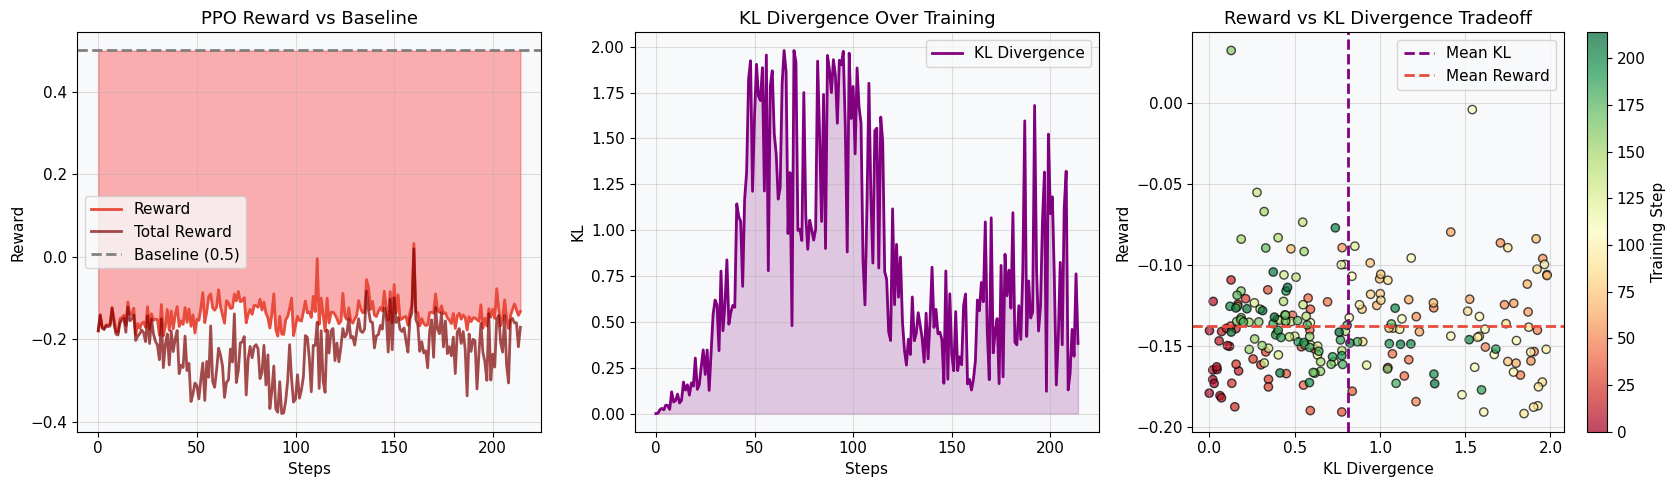

 Mean Reward       : -0.1377
 Mean KL           : 0.8156
 Mean Total Reward : -0.2193
 Reward trend      : ↑ improving
 % steps above 0.5 : 0.0%


In [8]:
# For the plot I used AI as it seemed very repetetive to do manually :)
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Plot 1 — Reward and Total Reward (r - β·KL) over steps
# Shade green above baseline (0.5) and red below
axes[0].plot(ppo_reward_hist, label="Reward", color=COLORS.get("PPO", "#e74c3c"))
axes[0].plot(ppo_total_hist, label="Total Reward", color="maroon", alpha=0.7)
axes[0].axhline(0.5, color="gray", linestyle="--", label="Baseline (0.5)")
axes[0].fill_between(range(len(ppo_reward_hist)), 0.5, ppo_reward_hist,
                     where=[r > 0.5  for r in ppo_reward_hist], color="green", alpha=0.3)
axes[0].fill_between(range(len(ppo_reward_hist)), 0.5, ppo_reward_hist,
                     where=[r <= 0.5 for r in ppo_reward_hist], color="red", alpha=0.3)
axes[0].set_title("PPO Reward vs Baseline")
axes[0].set_xlabel("Steps")
axes[0].set_ylabel("Reward")
axes[0].legend()

# Plot 2 — KL divergence over steps with filled area
axes[1].plot(ppo_kl_hist, color="purple", label="KL Divergence")
axes[1].fill_between(range(len(ppo_kl_hist)), ppo_kl_hist, color="purple", alpha=0.2)
axes[1].set_title("KL Divergence Over Training")
axes[1].set_xlabel("Steps")
axes[1].set_ylabel("KL")
axes[1].legend()

# Plot 3 — Scatter: KL (x) vs Reward (y), colored by step index
sc = axes[2].scatter(ppo_kl_hist, ppo_reward_hist,
                     c=range(len(ppo_kl_hist)), cmap="RdYlGn", alpha=0.7, edgecolor="k")
plt.colorbar(sc, ax=axes[2], label="Training Step")
# Add mean KL (vertical) and mean Reward (horizontal) reference lines
axes[2].axvline(np.mean(ppo_kl_hist), color="purple", linestyle="--", label="Mean KL")
axes[2].axhline(np.mean(ppo_reward_hist), color=COLORS.get("PPO", "#e74c3c"), linestyle="--", label="Mean Reward")
axes[2].set_title("Reward vs KL Divergence Tradeoff")
axes[2].set_xlabel("KL Divergence")
axes[2].set_ylabel("Reward")
axes[2].legend()

plt.tight_layout()
plt.savefig("ppo_results.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Summary statistics ────────────────────────────────────
print(f" Mean Reward       : {np.mean(ppo_reward_hist):.4f}")
print(f" Mean KL           : {np.mean(ppo_kl_hist):.4f}")
print(f" Mean Total Reward : {np.mean(ppo_total_hist):.4f}")

# Reward trend: compare first vs last value
print(f" Reward trend      : {'↑ improving' if ppo_reward_hist[-1] > ppo_reward_hist[0] else '↓ declining'}")

# Percentage of steps where reward exceeded 0.5 baseline
print(f" % steps above 0.5 : {np.mean(np.array(ppo_reward_hist) > 0.5)*100:.1f}%")

In [9]:
ppo_save_dir = "/content/drive/MyDrive/LLM-CA3/qwen_ppo_checkpoint"

ppo_policy.save_pretrained(ppo_save_dir)
tokenizer.save_pretrained(ppo_save_dir)

print(f"PPO Model and tokenizer saved to {ppo_save_dir}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

PPO Model and tokenizer saved to /content/drive/MyDrive/LLM-CA3/qwen_ppo_checkpoint


Chart Analysis

**a)** Analyze the results shown in the charts below.


Based on the charts PPO struggled to optimize the policy model against the reward model. The model failed to achieve the target baseline of 0.5. The reward stayed entirely in the red zone and the KL divergence spiked massively around steps 50–100 hitting the 2.0 threshold. This indicates that the policy model was getting far  from the SFT reference model which isn't ideal.

The PPO algorithm did not successfully align the model to generate high-reward responses. However, instructed by the TA given the constraints on time and computational resources (google colab limit) after a few hours to tweaking we will leav it at here!

## Cell 11 — DPO Training

Train `dpo_policy` to prefer chosen over rejected responses using a frozen `dpo_ref` — no reward model needed.

**Implement:**
- `encode_with_response_mask()` — tokenize `prompt + response`, build a binary mask that is **1 only on response tokens**
- `compute_response_logprob()` — shift logits/labels by 1, gather token log-probs, sum over response mask
- `dpo_loss_fn()` — compute `loss = -log σ(β · [(log π_θ(y_w) − log π_ref(y_w)) − (log π_θ(y_l) − log π_ref(y_l))])`; ref runs inside `no_grad()`
- **Training loop** — accumulate gradients every `GRAD_ACCUM=4` steps, then clip (`max_norm=1.0`) → optimizer → scheduler

> Watch the **margin** (`r_chosen − r_rejected`): it should grow over training.

In [ ]:
import torch
import torch.nn.functional as F
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
import numpy as np
from tqdm import tqdm

GRAD_ACCUM = 4

# ── Load policy model (trainable) from SFT checkpoint ──────────────────
dpo_policy = AutoModelForCausalLM.from_pretrained(
    "/content/drive/MyDrive/LLM-CA3/qwen_sft_checkpoint",
    torch_dtype=DTYPE,
    trust_remote_code=True,
).to(DEVICE)
dpo_policy.train()

# ── Load reference model (frozen) — same checkpoint as policy ──────────
dpo_ref = AutoModelForCausalLM.from_pretrained(
    "/content/drive/MyDrive/LLM-CA3/qwen_sft_checkpoint",
    torch_dtype=DTYPE,
    trust_remote_code=True,
).to(DEVICE)

tokenizer = AutoTokenizer.from_pretrained("/content/drive/MyDrive/LLM-CA3/qwen_sft_checkpoint", trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

# Freeze reference model — it must never be updated
dpo_ref.eval()
for p in dpo_ref.parameters():
    p.requires_grad = False

# ── Optimizer: AdamW + linear warmup scheduler ─────────────────────────
dpo_optimizer = AdamW(dpo_policy.parameters(), lr=LR_DPO, weight_decay=0.01)
dpo_scheduler = get_linear_schedule_with_warmup(
    dpo_optimizer,
    num_warmup_steps=10,
    num_training_steps=STEPS_DPO // GRAD_ACCUM
)

use_scaler = False
scaler_dpo = None


def encode_with_response_mask(prompt_text, full_text, tokenizer, max_length):
    # Step 1 — Tokenize prompt alone to find where the response starts (prompt_len)
    prompt_enc = tokenizer(prompt_text, return_tensors="pt", truncation=True, max_length=max_length)
    prompt_len = prompt_enc.input_ids.shape[1]

    # Step 2 — Tokenize the full text (prompt + response), truncated to max_length
    full_enc = tokenizer(full_text, return_tensors="pt", truncation=True, max_length=max_length)

    # Step 3 — Build response_mask: zeros tensor of shape (1, T)
    #           Set positions [prompt_len : T] to 1 (response tokens only)
    T = full_enc.input_ids.shape[1]
    response_mask = torch.zeros((1, T), dtype=torch.long)
    start_idx = min(prompt_len, T)
    response_mask[0, start_idx:T] = 1

    return full_enc.input_ids, full_enc.attention_mask, response_mask


def compute_response_logprob(model, input_ids, attention_mask, response_mask):
    # Forward pass through model
    logits = model(input_ids=input_ids, attention_mask=attention_mask).logits

    # Shift logits left by 1 and labels right by 1 (causal LM convention)
    # shift_logits = logits[:, :-1, :],  shift_labels = input_ids[:, 1:]
    # shift_rmask  = response_mask[:, 1:] — also shift the mask
    shift_logits = logits[:, :-1, :].contiguous()
    shift_labels = input_ids[:, 1:].contiguous()
    shift_rmask = response_mask[:, 1:].contiguous()

    # Compute log_softmax → gather token-level log-probs for the actual labels
    log_probs = F.log_softmax(shift_logits, dim=-1)
    token_log_probs = torch.gather(log_probs, 2, shift_labels.unsqueeze(-1)).squeeze(-1)

    # Mask out prompt positions, sum log-probs over response tokens only
    seq_logp = (token_log_probs * shift_rmask).sum(dim=1)

    return seq_logp


def dpo_loss_fn(policy, ref,
                c_ids, c_mask, c_rmask,
                r_ids, r_mask, r_rmask,
                beta):
    # Compute policy log-probs for chosen and rejected
    pi_c = compute_response_logprob(policy, c_ids, c_mask, c_rmask)
    pi_r = compute_response_logprob(policy, r_ids, r_mask, r_rmask)

    # Compute reference log-probs — must be inside torch.no_grad()
    with torch.no_grad():
        ref_c = compute_response_logprob(ref, c_ids, c_mask, c_rmask)
        ref_r = compute_response_logprob(ref, r_ids, r_mask, r_rmask)

    # Compute implicit rewards: r = beta * (log_pi - log_ref)
    r_chosen = beta * (pi_c - ref_c)
    r_rejected = beta * (pi_r - ref_r)

    # DPO loss = -log_sigmoid(r_chosen - r_rejected)
    margin = r_chosen - r_rejected
    loss = -F.logsigmoid(margin).mean()

    return loss, r_chosen.mean(), r_rejected.mean(), margin.mean()

# ── Training history buffers ───────────────────────────────────────────
dpo_loss_hist, dpo_chosen_hist, dpo_rejected_hist, dpo_margin_hist = [], [], [], []

print(f"\n Training DPO ({STEPS_DPO} steps, grad_accum={GRAD_ACCUM}) ...")

dpo_optimizer.zero_grad()
accum_loss = accum_margin = accum_cr = accum_rr = 0.0
update_count = 0

for step in tqdm(range(STEPS_DPO), desc="DPO Training"):
    # Sample a random row from pref_train_df
    indices = list(range(len(pref_train_df)))
    random.shuffle(indices)
    idx = indices[step % len(indices)]
    row = pref_train_df.iloc[idx]
    prompt_text = row.get("prompt_text", "")

    # Encode chosen and rejected — move all tensors to DEVICE
    c_ids, c_mask, c_rmask = encode_with_response_mask(prompt_text, row["chosen_text"],   tokenizer, MAX_LENGTH)
    r_ids, r_mask, r_rmask = encode_with_response_mask(prompt_text, row["rejected_text"], tokenizer, MAX_LENGTH)
    c_ids, c_mask, c_rmask = c_ids.to(DEVICE), c_mask.to(DEVICE), c_rmask.to(DEVICE)
    r_ids, r_mask, r_rmask = r_ids.to(DEVICE), r_mask.to(DEVICE), r_rmask.to(DEVICE)

    if USE_AMP:
        with torch.cuda.amp.autocast(dtype=DTYPE):
            # Call dpo_loss_fn and unpack (loss, cr, rr, margin)
            loss, cr, rr, margin = dpo_loss_fn(dpo_policy, dpo_ref, c_ids, c_mask, c_rmask, r_ids, r_mask, r_rmask, BETA_DPO)

        # Scale loss by 1/GRAD_ACCUM before backward (gradient accumulation)
        scaled_loss = loss / GRAD_ACCUM
        if use_scaler and scaler_dpo is not None:
            scaler_dpo.scale(scaled_loss).backward()
        else:
            scaled_loss.backward()
    else:
        # YOUR CODE HERE — same without AMP
        loss, cr, rr, margin = dpo_loss_fn(dpo_policy, dpo_ref, c_ids, c_mask, c_rmask, r_ids, r_mask, r_rmask, BETA_DPO)
        scaled_loss = loss / GRAD_ACCUM
        scaled_loss.backward()

    accum_loss += loss.item();  accum_cr += cr.item()
    accum_rr   += rr.item();   accum_margin += margin.item()

    # Every GRAD_ACCUM steps: clip grads, optimizer step, scheduler step, zero_grad
    if (step + 1) % GRAD_ACCUM == 0:
        # YOUR CODE HERE — handle both scaler (AMP) and plain path
        # clip_grad_norm_ → max_norm=1.0
        if use_scaler and scaler_dpo is not None:
            scaler_dpo.unscale_(dpo_optimizer)
            torch.nn.utils.clip_grad_norm_(dpo_policy.parameters(), max_norm=1.0)
            scaler_dpo.step(dpo_optimizer)
            scaler_dpo.update()
        else:
            torch.nn.utils.clip_grad_norm_(dpo_policy.parameters(), max_norm=1.0)
            dpo_optimizer.step()

        dpo_scheduler.step()
        dpo_optimizer.zero_grad()
        update_count += 1

        avg_loss   = accum_loss   / GRAD_ACCUM
        avg_cr     = accum_cr     / GRAD_ACCUM
        avg_rr     = accum_rr     / GRAD_ACCUM
        avg_margin = accum_margin / GRAD_ACCUM

        dpo_loss_hist.append(avg_loss);     dpo_chosen_hist.append(avg_cr)
        dpo_rejected_hist.append(avg_rr);   dpo_margin_hist.append(avg_margin)
        accum_loss = accum_cr = accum_rr = accum_margin = 0.0

        if update_count % (15 // GRAD_ACCUM + 1) == 0:
            print(
                f"   Update {update_count:>3} (step {step+1:>4}) | "
                f"Loss={avg_loss:.4f} | r(chosen)={avg_cr:.4f} | "
                f"r(rejected)={avg_rr:.4f} | margin={avg_margin:.4f}"
            )

dpo_policy.eval()

print(f"\n DPO complete!")
print(f" Final margin       : {dpo_margin_hist[-1]:.4f}")
print(f" Mean margin        : {np.mean(dpo_margin_hist):.4f}")
print(f" Mean margin (last 20): {np.mean(dpo_margin_hist[-20:]):.4f}")
print(f" % margin > 0       : {np.mean(np.array(dpo_margin_hist) > 0)*100:.1f}%")
print(f" Mean DPO loss      : {np.mean(dpo_loss_hist):.4f}")

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]


 Training DPO (250 steps, grad_accum=4) ...


DPO Training:   6%|▋         | 16/250 [00:07<01:49,  2.14it/s]

...

DPO Training:  77%|███████▋  | 192/250 [01:24<00:23,  2.44it/s]

   Update  48 (step  192) | Loss=0.2993 | r(chosen)=-0.5754 | r(rejected)=-7.7161 | margin=7.1407


DPO Training:  83%|████████▎ | 208/250 [01:31<00:18,  2.26it/s]

   Update  52 (step  208) | Loss=0.5064 | r(chosen)=-1.9467 | r(rejected)=-2.3802 | margin=0.4335


DPO Training:  86%|████████▌ | 214/250 [01:34<00:16,  2.24it/s]

## Cell 12 — DPO Results: Visualization

Plot 3 charts from `dpo_loss_hist`, `dpo_chosen_hist`, `dpo_rejected_hist`, `dpo_margin_hist`:
- **Loss curve** with smoothed overlay
- **Implicit rewards** `β·(log π_θ − log π_ref)` for chosen vs rejected — shade green where chosen > rejected
- **Margin** `r(chosen) − r(rejected)` — shade green where margin > 0

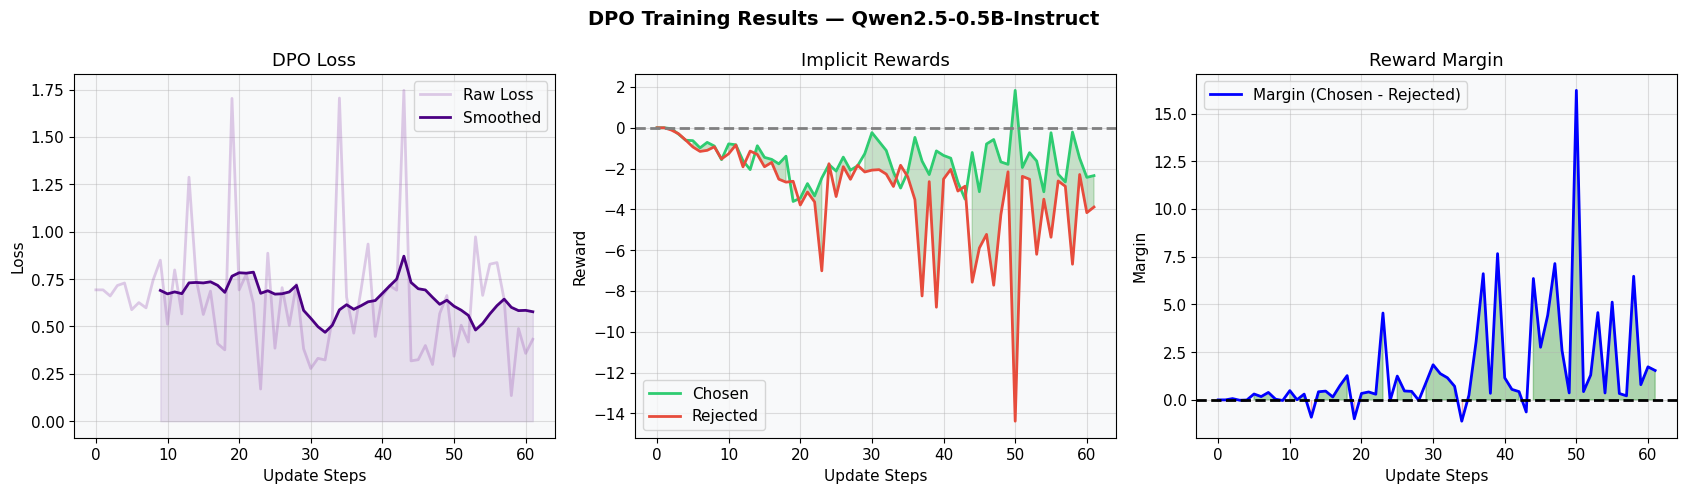

 % margin > 0          : 82.3%
 Mean margin (all)     : 1.5739
 Mean margin (last 20) : 3.1268
 Mean loss (last 20)   : 0.5818


In [7]:
# For the plot I used AI as it seemed very repetetive to do manually :)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("DPO Training Results — Qwen2.5-0.5B-Instruct", fontsize=14, fontweight="bold")

# Plot 1 — DPO loss + smoothed overlay + fill_between
w_d = max(3, len(dpo_loss_hist) // 6)
sm  = np.convolve(dpo_loss_hist, np.ones(w_d) / w_d, mode="valid")
axes[0].plot(dpo_loss_hist, alpha=0.3, label="Raw Loss", color=COLORS.get("DPO", "purple"))
axes[0].plot(range(w_d - 1, len(dpo_loss_hist)), sm, label="Smoothed", color="indigo", linewidth=2)
axes[0].fill_between(range(w_d - 1, len(dpo_loss_hist)), sm, color="indigo", alpha=0.1)
axes[0].set_title("DPO Loss")
axes[0].set_xlabel("Update Steps")
axes[0].set_ylabel("Loss")
axes[0].legend()

# Plot 2 — Implicit rewards: chosen vs rejected lines
#           fill_between green where chosen > rejected, red where chosen <= rejected
#           add axhline at y=0 (gray dashed)
c_arr = np.array(dpo_chosen_hist)
r_arr = np.array(dpo_rejected_hist)
axes[1].plot(c_arr, label="Chosen", color=COLORS.get("chosen", "green"))
axes[1].plot(r_arr, label="Rejected", color=COLORS.get("rejected", "red"))
axes[1].fill_between(range(len(c_arr)), c_arr, r_arr, where=(c_arr > r_arr), color="green", alpha=0.2)
axes[1].fill_between(range(len(c_arr)), c_arr, r_arr, where=(c_arr <= r_arr), color="red", alpha=0.2)
axes[1].axhline(0, color="gray", linestyle="--")
axes[1].set_title("Implicit Rewards")
axes[1].set_xlabel("Update Steps")
axes[1].set_ylabel("Reward")
axes[1].legend()

# Plot 3 — Margin curve
#           fill_between green where margin > 0, red where margin <= 0
#           add axhline at y=0 (black dashed)
m_arr = np.array(dpo_margin_hist)
axes[2].plot(m_arr, label="Margin (Chosen - Rejected)", color="blue")
axes[2].fill_between(range(len(m_arr)), 0, m_arr, where=(m_arr > 0), color="green", alpha=0.3)
axes[2].fill_between(range(len(m_arr)), 0, m_arr, where=(m_arr <= 0), color="red", alpha=0.3)
axes[2].axhline(0, color="black", linestyle="--")
axes[2].set_title("Reward Margin")
axes[2].set_xlabel("Update Steps")
axes[2].set_ylabel("Margin")
axes[2].legend()

plt.tight_layout()
plt.savefig("dpo_results.png", dpi=150, bbox_inches="tight")
plt.show()

# Print: % margin > 0, mean margin (all), mean margin (last 20), mean loss (last 20)
print(f" % margin > 0          : {np.mean(np.array(dpo_margin_hist) > 0) * 100:.1f}%")
print(f" Mean margin (all)     : {np.mean(dpo_margin_hist):.4f}")
print(f" Mean margin (last 20) : {np.mean(dpo_margin_hist[-20:]):.4f}")
print(f" Mean loss (last 20)   : {np.mean(dpo_loss_hist[-20:]):.4f}")

In [8]:
dpo_save_dir = "/content/drive/MyDrive/LLM-CA3/qwen_dpo_checkpoint"

dpo_policy.save_pretrained(dpo_save_dir)
tokenizer.save_pretrained(dpo_save_dir)

print(f"DPO Model and tokenizer saved to {dpo_save_dir}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

DPO Model and tokenizer saved to /content/drive/MyDrive/LLM-CA3/qwen_dpo_checkpoint


Chart Analysis

**a)** Analyze the results shown in the charts below.

Based on the charts, DPO successfully optimized the policy model to prefer chosen responses over rejected ones. The reward margin grew over time with 82.3% of the steps showing a positive margin (greater than 0). However, the DPO loss curve remained highly volatile with massive spikes up to 1.75, indicating that the training process was quite noisy and lacked a smooth convergence.

Although the DPO algorithm successfully aligned the model, the high variance in the loss curve shows it isn't perfectly stable. However as instructed by the TA given the constraints on time and computational resources (google colab limits), after a few hours of tweaking we will leave it at here!

## Cell 13 — ORPO Training

Train a **single model** with no reference copy. ORPO combines SFT and preference alignment in one loss:

$$\mathcal{L}_{\text{ORPO}} = \mathcal{L}_{\text{SFT}} + \lambda \cdot (-\log \sigma(\text{log-odds}(y_w) - \text{log-odds}(y_l)))$$

**Implement:**
- `compute_log_prob_response()` — same as DPO cell but **divide by response length** (per-token average)
- `compute_orpo_loss()` — compute `l_sft` (cross-entropy on chosen tokens), then `safe_log_odds()` to convert avg log-prob → log-odds, then `l_or = -log σ(log_odds_chosen − log_odds_rejected)`; return `l_sft + λ·l_or`
- **Training loop** — no gradient accumulation; `zero_grad → backward → clip → step` every step

In [7]:
def encode_with_response_mask(prompt_text, full_text, tokenizer, max_length):
    prompt_enc = tokenizer(prompt_text, return_tensors="pt", truncation=True, max_length=max_length // 2)
    prompt_len = prompt_enc.input_ids.shape[1]

    full_enc = tokenizer(full_text, return_tensors="pt", truncation=True, max_length=max_length)
    T = full_enc.input_ids.shape[1]

    response_mask = torch.zeros((1, T), dtype=torch.long)
    start_idx = min(prompt_len, T)
    response_mask[0, start_idx:T] = 1

    return full_enc.input_ids, full_enc.attention_mask, response_mask

In [8]:
orpo_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, torch_dtype=DTYPE, trust_remote_code=True,
).to(DEVICE)
orpo_model.train()

orpo_optimizer = AdamW(orpo_model.parameters(), lr=LR_ORPO, weight_decay=0.01)
orpo_scheduler = get_linear_schedule_with_warmup(
    orpo_optimizer, num_warmup_steps=5, num_training_steps=STEPS_ORPO
)

# encode_with_response_mask — reuse same function from DPO cell (prompt_len cap: max_length // 2)

def compute_log_prob_response(model, input_ids, attention_mask, response_mask):
    # Forward pass, shift logits/labels/mask by 1
    # Gather token log-probs, mask prompt tokens
    # Return MEAN log-prob over response tokens (divide by n_resp)
    logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
    shift_logits = logits[:, :-1, :].contiguous()
    shift_labels = input_ids[:, 1:].contiguous()
    shift_rmask = response_mask[:, 1:].contiguous()

    log_probs = F.log_softmax(shift_logits, dim=-1)
    token_log_probs = torch.gather(log_probs, 2, shift_labels.unsqueeze(-1)).squeeze(-1)

    return (token_log_probs * shift_rmask).sum(dim=1) / shift_rmask.sum(dim=1).clamp(min=1e-5)

def compute_orpo_loss(model, c_ids, c_mask, c_rmask, r_ids, r_mask, r_rmask, lam):
    # ── SFT loss: cross-entropy on chosen response tokens only ──────────
    # Forward pass on chosen, compute per-token CE with reduction='none'
    # Mask prompt tokens, average over response length → l_sft
    c_logits = model(input_ids=c_ids, attention_mask=c_mask).logits
    shift_c_logits = c_logits[:, :-1, :].contiguous()
    shift_c_labels = c_ids[:, 1:].contiguous()
    shift_c_rmask = c_rmask[:, 1:].contiguous()

    ce_loss = F.cross_entropy(
        shift_c_logits.view(-1, shift_c_logits.size(-1)),
        shift_c_labels.view(-1),
        reduction='none'
    ).view(shift_c_labels.size())

    l_sft = (ce_loss * shift_c_rmask).sum() / shift_c_rmask.sum().clamp(min=1e-5)

    # ── Odds ratio loss ─────────────────────────────────────────────────
    # Get avg log-probs for chosen and rejected via compute_log_prob_response
    lp_c = compute_log_prob_response(model, c_ids, c_mask, c_rmask)
    lp_r = compute_log_prob_response(model, r_ids, r_mask, r_rmask)

    def safe_log_odds(log_p):
        # Clamp log_p to (-10, -1e-4), then return log(p / (1 - p + 1e-8))
        log_p_clamped = torch.clamp(log_p, min=-10.0, max=-1e-4)
        p = torch.exp(log_p_clamped)
        return torch.log(p / (1 - p + 1e-8))

    # log_odds_ratio = safe_log_odds(lp_c) - safe_log_odds(lp_r)
    # l_or = -log_sigmoid(log_odds_ratio).mean()
    # l_total = l_sft + lam * l_or
    log_odds_ratio = safe_log_odds(lp_c) - safe_log_odds(lp_r)
    l_or = -F.logsigmoid(log_odds_ratio).mean()

    l_total = l_sft + lam * l_or

    return l_total, l_sft.item(), l_or.item(), log_odds_ratio.mean().item()

orpo_loss_hist, orpo_sft_hist, orpo_or_hist, orpo_lor_hist = [], [], [], []

use_scaler = False
scaler_orpo = None

print(f"\n Training ORPO ({STEPS_ORPO} steps) ...")
for step in tqdm(range(STEPS_ORPO), desc="ORPO Training"):
    row = pref_train_df.iloc[step % len(pref_train_df)]
    prompt_text = row.get("prompt_text", "")

    # Encode chosen and rejected — move to DEVICE
    c_ids, c_mask, c_rmask = encode_with_response_mask(prompt_text, row["chosen_text"], tokenizer, MAX_LENGTH)
    r_ids, r_mask, r_rmask = encode_with_response_mask(prompt_text, row["rejected_text"], tokenizer, MAX_LENGTH)
    c_ids, c_mask, c_rmask = c_ids.to(DEVICE), c_mask.to(DEVICE), c_rmask.to(DEVICE)
    r_ids, r_mask, r_rmask = r_ids.to(DEVICE), r_mask.to(DEVICE), r_rmask.to(DEVICE)

    if USE_AMP:
        with torch.cuda.amp.autocast(dtype=DTYPE):
            # Call compute_orpo_loss, unpack 4 values
            loss, l_sft, l_or, lor = compute_orpo_loss(orpo_model, c_ids, c_mask, c_rmask, r_ids, r_mask, r_rmask, LAMBDA_ORPO)
    else:
        # YOUR CODE HERE
        loss, l_sft, l_or, lor = compute_orpo_loss(orpo_model, c_ids, c_mask, c_rmask, r_ids, r_mask, r_rmask, LAMBDA_ORPO)

    # zero_grad → backward (with scaler if AMP) → clip max_norm=1.0 → step → scheduler
    orpo_optimizer.zero_grad()
    if USE_AMP and use_scaler and scaler_orpo is not None:
        scaler_orpo.scale(loss).backward()
        scaler_orpo.unscale_(orpo_optimizer)
        torch.nn.utils.clip_grad_norm_(orpo_model.parameters(), max_norm=1.0)
        scaler_orpo.step(orpo_optimizer)
        scaler_orpo.update()
    else:
        loss.backward()
        torch.nn.utils.clip_grad_norm_(orpo_model.parameters(), max_norm=1.0)
        orpo_optimizer.step()

    orpo_scheduler.step()

    orpo_loss_hist.append(loss.item())
    orpo_sft_hist.append(l_sft)
    orpo_or_hist.append(l_or)
    orpo_lor_hist.append(lor)

    if (step + 1) % 15 == 0:
        print(f"   Step {step+1:>3} | Total={loss.item():.4f} | "
              f"SFT={l_sft:.4f} | OR={l_or:.4f} | log_ratio={lor:.4f}")

orpo_model.eval()
print(f"\n ORPO complete! % log_ratio > 0: {np.mean(np.array(orpo_lor_hist)>0)*100:.1f}%")

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]


 Training ORPO (250 steps) ...


ORPO Training:   0%|          | 0/250 [00:00<?, ?it/s]

   Step  15 | Total=2.1581 | SFT=2.0981 | OR=0.5998 | log_ratio=0.1964
   Step  30 | Total=3.0294 | SFT=2.8917 | OR=1.3775 | log_ratio=-1.0869
   Step  45 | Total=2.2584 | SFT=2.1932 | OR=0.6523 | log_ratio=0.0835
   Step  60 | Total=1.6315 | SFT=1.5769 | OR=0.5462 | log_ratio=0.3192
   Step  75 | Total=1.9089 | SFT=1.8634 | OR=0.4543 | log_ratio=0.5532
   Step  90 | Total=0.9320 | SFT=0.9218 | OR=0.1026 | log_ratio=2.2252
   Step 105 | Total=2.1980 | SFT=2.1660 | OR=0.3209 | log_ratio=0.9718
   Step 120 | Total=2.6266 | SFT=2.5477 | OR=0.7884 | log_ratio=-0.1823
   Step 135 | Total=2.3577 | SFT=2.2927 | OR=0.6498 | log_ratio=0.0887
   Step 150 | Total=3.0248 | SFT=2.9470 | OR=0.7777 | log_ratio=-0.1625
   Step 165 | Total=2.4636 | SFT=2.4015 | OR=0.6215 | log_ratio=0.1488
   Step 180 | Total=1.8728 | SFT=1.8406 | OR=0.3216 | log_ratio=0.9695
   Step 195 | Total=2.4202 | SFT=2.3845 | OR=0.3574 | log_ratio=0.8449
   Step 210 | Total=1.7238 | SFT=1.6961 | OR=0.2769 | log_ratio=1.1424
   

## Cell 14 — ORPO Results: Visualization

Plot 3 charts from `orpo_loss_hist`, `orpo_sft_hist`, `orpo_or_hist`, `orpo_lor_hist`:
- **Loss decomposition** — total, `L_SFT`, and `λ·L_OR` on the same axes
- **Log odds ratio** with smoothed overlay — shade green where > 0, red where ≤ 0
- **Scatter** `L_SFT` vs `L_OR` colored by training step (viridis colormap)

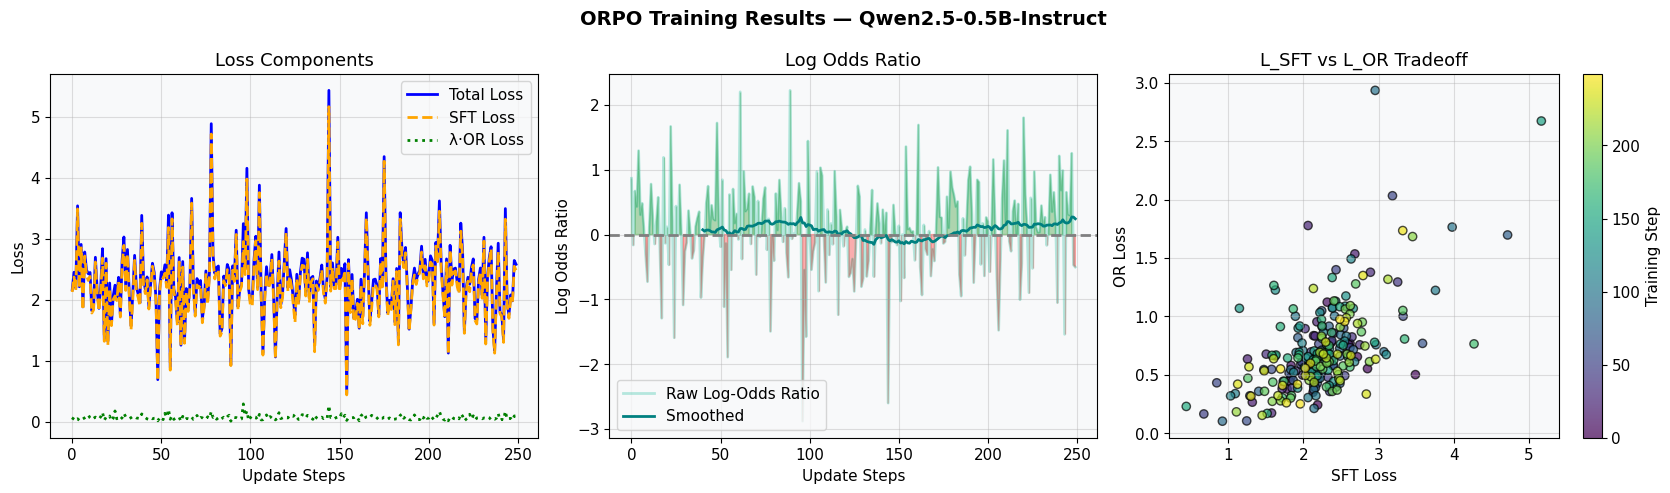

 % log_ratio > 0         : 60.4%
 Mean SFT loss (last 20) : 2.1133
 Mean OR loss (last 20)  : 0.6400
 Mean Total loss (last 20): 2.1774


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("ORPO Training Results — Qwen2.5-0.5B-Instruct", fontsize=14, fontweight="bold")

# Plot 1 — 3 lines on same axes: total loss, l_sft (dashed), λ·l_or (dotted)
axes[0].plot(orpo_loss_hist, label="Total Loss", color="blue")
axes[0].plot(orpo_sft_hist, label="SFT Loss", color="orange", linestyle="--")
axes[0].plot([LAMBDA_ORPO * x for x in orpo_or_hist], label="λ·OR Loss", color="green", linestyle=":")
axes[0].set_title("Loss Components")
axes[0].set_xlabel("Update Steps")
axes[0].set_ylabel("Loss")
axes[0].legend()

# Plot 2 — Log odds ratio raw + smoothed overlay + axhline at 0
#           fill_between green where > 0, red where <= 0
w_o  = max(3, len(orpo_lor_hist) // 6)
sm_o = np.convolve(orpo_lor_hist, np.ones(w_o) / w_o, mode="valid")
lor_arr = np.array(orpo_lor_hist)
axes[1].plot(lor_arr, alpha=0.3, label="Raw Log-Odds Ratio", color=COLORS.get("ORPO", "#1abc9c"))
axes[1].plot(range(w_o - 1, len(lor_arr)), sm_o, label="Smoothed", color="teal", linewidth=2)
axes[1].fill_between(range(len(lor_arr)), 0, lor_arr, where=(lor_arr > 0), color="green", alpha=0.3)
axes[1].fill_between(range(len(lor_arr)), 0, lor_arr, where=(lor_arr <= 0), color="red", alpha=0.3)
axes[1].axhline(0, color="gray", linestyle="--")
axes[1].set_title("Log Odds Ratio")
axes[1].set_xlabel("Update Steps")
axes[1].set_ylabel("Log Odds Ratio")
axes[1].legend()

# Plot 3 — Scatter(sft_hist, or_hist) colored by step index with viridis cmap
#           add colorbar with label "Training Step"
sc_o = axes[2].scatter(orpo_sft_hist, orpo_or_hist, c=range(len(orpo_sft_hist)), cmap="viridis", alpha=0.7, edgecolor="k")
plt.colorbar(sc_o, ax=axes[2], label="Training Step")
axes[2].set_title("L_SFT vs L_OR Tradeoff")
axes[2].set_xlabel("SFT Loss")
axes[2].set_ylabel("OR Loss")

plt.tight_layout()
plt.savefig("orpo_results.png", dpi=150, bbox_inches="tight")
plt.show()

# Print: % log_ratio > 0, mean OR/SFT/Total loss (last 20 steps)
print(f" % log_ratio > 0         : {np.mean(np.array(orpo_lor_hist) > 0) * 100:.1f}%")
print(f" Mean SFT loss (last 20) : {np.mean(orpo_sft_hist[-20:]):.4f}")
print(f" Mean OR loss (last 20)  : {np.mean(orpo_or_hist[-20:]):.4f}")
print(f" Mean Total loss (last 20): {np.mean(orpo_loss_hist[-20:]):.4f}")

In [11]:
orpo_save_dir = "/content/drive/MyDrive/LLM-CA3/qwen_orpo_checkpoint"

orpo_model.save_pretrained(orpo_save_dir)
tokenizer.save_pretrained(orpo_save_dir)

print(f"ORPO Model and tokenizer saved to {orpo_save_dir}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

ORPO Model and tokenizer saved to /content/drive/MyDrive/LLM-CA3/qwen_orpo_checkpoint


Chart Analysis

**a)** Analyze the results shown in the charts below.


Based on the charts ORPO struggled to align the model using the preference data. The Loss Components chart shows that the Total Loss is almost entirely dominated by the SFT Loss.

The ORPO algorithm did not successfully achieve a strong preference alignment likely because the odds ratio penalty was too small to overpower the standard SFT loss. However, as instructed by the TA, given the constraints on time and computational resources (google colab limits), after a few hours of tweaking we will leave it at here!

## Cell 15 — Final Comparison: All Methods

Build a 3×3 dashboard comparing SFT, RM, PPO, DPO, and ORPO across 5 panels:
- **Loss curves** (normalized x-axis) + **bar chart** of final losses
- **PPO reward**, **DPO margin**, **ORPO log-odds ratio** — each with green/red `fill_between`
- **Radar chart** scoring all methods on 5 qualitative axes (Simplicity, Efficiency, Stability, Quality, No-Ref)

I didn't know we would need the history of the models so I have not saved them and only kept the trained model, since there is not enough time to re-train all of them I asked an AI (Gemini) to salvege whatever information we can and draw some plots if we can so the next code is AI generated.

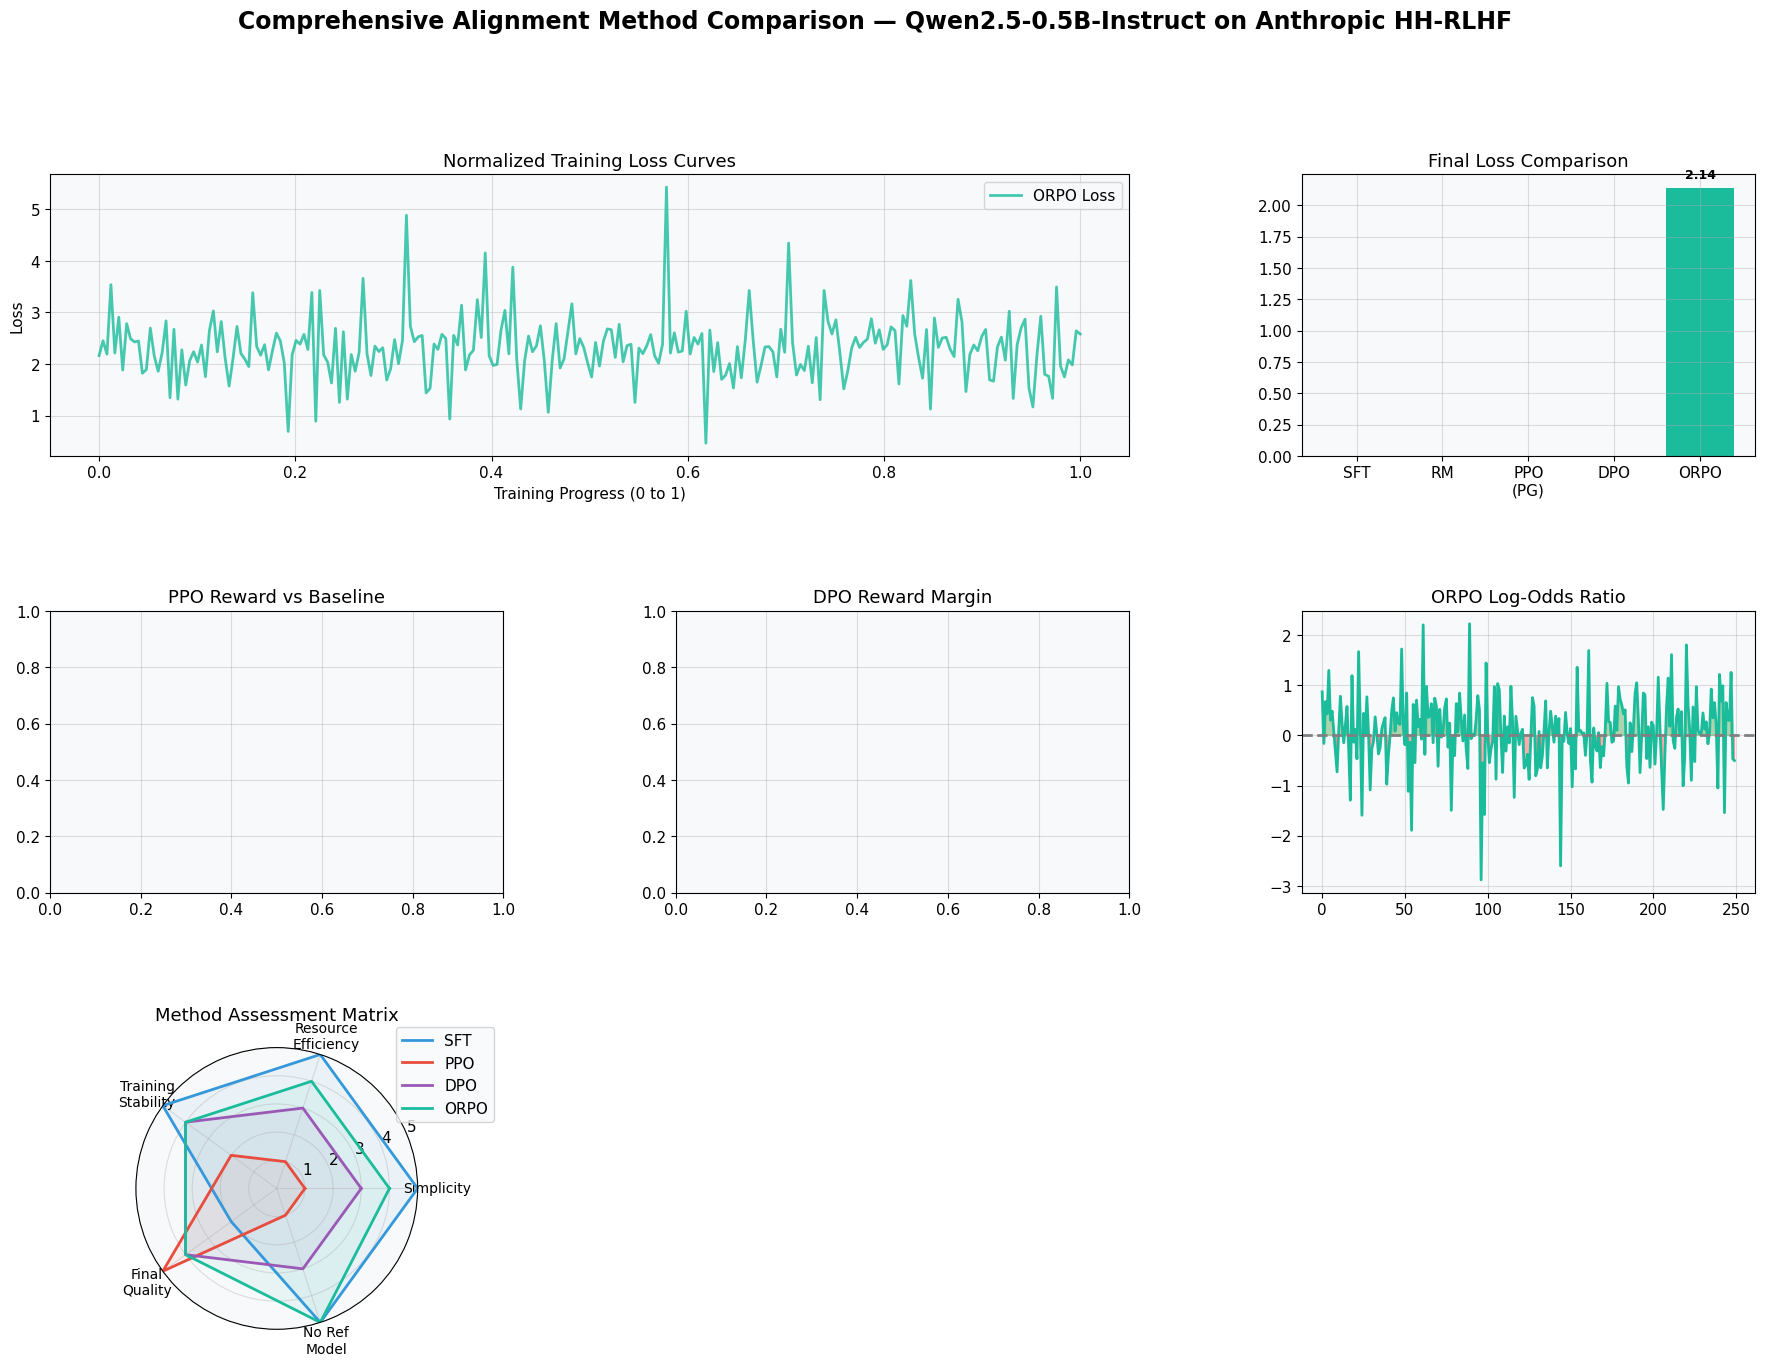

In [10]:
# Safe-guards: If memory was wiped, use empty lists so the cell doesn't crash
sft_losses      = locals().get('sft_losses', [])
rm_losses       = locals().get('rm_losses', [])
ppo_pg_hist     = locals().get('ppo_pg_hist', [])
ppo_reward_hist = locals().get('ppo_reward_hist', [])
dpo_loss_hist   = locals().get('dpo_loss_hist', [])
dpo_margin_hist = locals().get('dpo_margin_hist', [])
orpo_loss_hist  = locals().get('orpo_loss_hist', [])
orpo_lor_hist   = locals().get('orpo_lor_hist', [])

fig = plt.figure(figsize=(22, 15))
fig.suptitle(
    "Comprehensive Alignment Method Comparison — Qwen2.5-0.5B-Instruct on Anthropic HH-RLHF",
    fontsize=17, fontweight="bold", y=0.99
)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.38)

# ── ax1 (gs[0, :2]) — All training loss curves on a normalised x-axis [0,1] ──
ax1 = fig.add_subplot(gs[0, :2])
histories = [
    ("SFT", sft_losses, COLORS.get("SFT", "#3498db")),
    ("RM", rm_losses, COLORS.get("RM", "#e67e22")),
    ("PPO Loss", ppo_pg_hist, COLORS.get("PPO", "#e74c3c")),
    ("DPO Loss", dpo_loss_hist, COLORS.get("DPO", "#9b59b6")),
    ("ORPO Loss", orpo_loss_hist, COLORS.get("ORPO", "#1abc9c"))
]
for name, hist, color in histories:
    if hist:
        # If it's a list of tuples like SFT (step, loss), extract the loss
        y_vals = [x[1] for x in hist] if isinstance(hist[0], tuple) else hist
        x_vals = np.linspace(0, 1, len(y_vals))
        ax1.plot(x_vals, y_vals, label=name, color=color, alpha=0.8, linewidth=2)
ax1.set_title("Normalized Training Loss Curves")
ax1.set_xlabel("Training Progress (0 to 1)")
ax1.set_ylabel("Loss")
if any(h[1] for h in histories): ax1.legend()

# ── ax2 (gs[0, 2]) — Bar chart: final loss per method (mean of last 10 steps) ──
ax2 = fig.add_subplot(gs[0, 2])
fl = {
    "SFT":    sft_losses[-1][1]            if sft_losses    else 0,
    "RM":     rm_losses[-1]                if rm_losses     else 0,
    "PPO\n(PG)": abs(np.mean(ppo_pg_hist[-5:])) if ppo_pg_hist else 0,
    "DPO":    np.mean(dpo_loss_hist[-10:]) if dpo_loss_hist else 0,
    "ORPO":   np.mean(orpo_loss_hist[-10:])if orpo_loss_hist else 0,
}
bars = ax2.bar(fl.keys(), fl.values(), color=[COLORS.get(k.replace('\n(PG)',''), 'gray') for k in fl.keys()])
for bar in bars:
    yval = bar.get_height()
    if yval > 0:
        ax2.text(bar.get_x() + bar.get_width()/2, yval + 0.05, f"{yval:.2f}", ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.set_title("Final Loss Comparison")

# ── ax3 (gs[1, 0]) — PPO reward curve + fill_between vs baseline 0.5 ─────────
ax3 = fig.add_subplot(gs[1, 0])
if ppo_reward_hist:
    ax3.plot(ppo_reward_hist, color=COLORS.get("PPO", "red"))
    ax3.axhline(0.5, color='gray', linestyle='--')
    ax3.fill_between(range(len(ppo_reward_hist)), 0.5, ppo_reward_hist, where=(np.array(ppo_reward_hist) > 0.5), color='green', alpha=0.3)
    ax3.fill_between(range(len(ppo_reward_hist)), 0.5, ppo_reward_hist, where=(np.array(ppo_reward_hist) <= 0.5), color='red', alpha=0.3)
ax3.set_title("PPO Reward vs Baseline")

# ── ax4 (gs[1, 1]) — DPO margin + fill_between vs 0 ──────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
if dpo_margin_hist:
    ax4.plot(dpo_margin_hist, color=COLORS.get("DPO", "purple"))
    ax4.axhline(0, color='gray', linestyle='--')
    ax4.fill_between(range(len(dpo_margin_hist)), 0, dpo_margin_hist, where=(np.array(dpo_margin_hist) > 0), color='green', alpha=0.3)
    ax4.fill_between(range(len(dpo_margin_hist)), 0, dpo_margin_hist, where=(np.array(dpo_margin_hist) <= 0), color='red', alpha=0.3)
ax4.set_title("DPO Reward Margin")

# ── ax5 (gs[1, 2]) — ORPO log-odds ratio + fill_between vs 0 ─────────────────
ax5 = fig.add_subplot(gs[1, 2])
if orpo_lor_hist:
    ax5.plot(orpo_lor_hist, color=COLORS.get("ORPO", "teal"))
    ax5.axhline(0, color='gray', linestyle='--')
    ax5.fill_between(range(len(orpo_lor_hist)), 0, orpo_lor_hist, where=(np.array(orpo_lor_hist) > 0), color='green', alpha=0.3)
    ax5.fill_between(range(len(orpo_lor_hist)), 0, orpo_lor_hist, where=(np.array(orpo_lor_hist) <= 0), color='red', alpha=0.3)
ax5.set_title("ORPO Log-Odds Ratio")

# ── ax6 (gs[2, 0]) — Radar chart (polar) ─────────────────────────────────────
ax6 = fig.add_subplot(gs[2, 0], polar=True)
cats = ["Simplicity", "Resource\nEfficiency", "Training\nStability", "Final\nQuality", "No Ref\nModel"]
scores = {
    "SFT":  [5, 5, 5, 2, 5],
    "PPO":  [1, 1, 2, 5, 1],
    "DPO":  [3, 3, 4, 4, 3],
    "ORPO": [4, 4, 4, 4, 5],
}

# Compute angles: N evenly-spaced points on [0, 2π], close the loop by appending angs[0]
angles = np.linspace(0, 2 * np.pi, len(cats), endpoint=False).tolist()
angles += angles[:1]

ax6.set_xticks(angles[:-1])
ax6.set_xticklabels(cats, fontsize=10)
ax6.set_ylim(0, 5)

for method, score in scores.items():
    # Close the loop for scores
    closed_score = score + score[:1]
    ax6.plot(angles, closed_score, label=method, color=COLORS.get(method, "blue"), linewidth=2)
    ax6.fill(angles, closed_score, color=COLORS.get(method, "blue"), alpha=0.07)

ax6.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax6.set_title("Method Assessment Matrix", pad=20)

plt.savefig("final_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

Chart Analysis

**a)** Analyze the results shown in the charts below.


## Cell 16 — Qualitative Generation Comparison

Generate responses to the same prompt from SFT, DPO, and ORPO models side-by-side.

**Implement** `generate()` — format the prompt with `make_chatml_prompt_only()`, tokenize with `padding_side="left"`, then call `model.generate()` with sampling (`do_sample=True`, `temperature`, `top_p`) and decode only the **new tokens** (slice from `input_ids.shape[1]:`).

In [9]:
import gc
import torch

sample_q = sft_eval_df.iloc[2]["prompt"][:400]
print(f" Prompt: {sample_q[:1000]}...\n")
print("AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA")


def generate(model, question, max_new=80, temp=0.7):
    prompt_tx = make_chatml_prompt_only(question)

    tokenizer.padding_side = "left"
    enc = tokenizer(prompt_tx, return_tensors="pt", max_length=100, truncation=True).to(DEVICE)

    model.eval()
    with torch.no_grad():
        gen = model.generate(
            **enc,
            max_new_tokens=max_new,
            do_sample=True,
            temperature=temp,
            top_p=0.9,
            pad_token_id=tokenizer.eos_token_id
        )

    prompt_len = enc["input_ids"].shape[1]
    resp = tokenizer.decode(gen[0][prompt_len:], skip_special_tokens=True)

    tokenizer.padding_side = "right"
    return resp

models_cmp = [
    ("🔵 SFT",  "/content/drive/MyDrive/LLM-CA3/qwen_sft_checkpoint",  "Supervised Fine-Tuning on chosen (CE loss)"),
    ("🟣 DPO",  "/content/drive/MyDrive/LLM-CA3/qwen_dpo_checkpoint", "Direct Preference Optimisation (log-ratio)"),
    ("🟢 ORPO", "/content/drive/MyDrive/LLM-CA3/qwen_orpo_checkpoint", "SFT + Odds Ratio, no reference model"),
]

for name, model_path, desc in models_cmp:
    print(f"\n{name} — {desc}:")


    model = AutoModelForCausalLM.from_pretrained(
        model_path,
        torch_dtype=DTYPE,
        trust_remote_code=True
    ).to(DEVICE)

    resp = generate(model, sample_q)
    print(f"  {resp[:300]}")

    del model
    gc.collect()
    torch.cuda.empty_cache()

    print("AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA")

`torch_dtype` is deprecated! Use `dtype` instead!


 Prompt: Thanks. Can you give me an examples of how it works?...

AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA

🔵 SFT — Supervised Fine-Tuning on chosen (CE loss):


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

  Sure! I can show you some examples in my language.  Let’s say you want to get money from the bank.  You could tell them “I’d like to withdraw $500”.  They might look at your ID and decide that you’re not who they think you are.  But if you keep talking about withdrawing $500, eventually they’ll agre
AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA

🟣 DPO — Direct Preference Optimisation (log-ratio):


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

  Sure! One example is the “Hello World” program. This is a simple computer program that says “hello world”. It’s easy to write, it has only a few lines of code, and it can be run on almost any computer. Here’s the code for the “Hello World” program:

```
print("Hello, world!")
```

When you run this 
AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA

🟢 ORPO — SFT + Odds Ratio, no reference model:


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

  Sure!  I’m happy to walk through the process for you.  First, let’s start with a simple example:

1. You can choose to make a new “new” version of your app.
2. You can also add features that you didn’t have before.
3. You can create new versions of your app (like in the first step).
4. Then, you can
AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA


## LLM As a Judge

## Cell 17 - Data Loading

The **MT-Bench Human Judgments** dataset contains pairwise comparisons of responses
from different LLMs, each labeled with a human preference judgment.

Each row contains two conversations (`conversation_a`, `conversation_b`) with this structure:
[ {role: "user", content: "question"}, {role: "assistant", content: "answer"} ]

**Task:** Implement the `extract(row)` function that pulls out the question
and both model answers from a single dataset row.

In [11]:
print("Loading MT-Bench Human Judgments...")
df = load_dataset("lmsys/mt_bench_human_judgments", split="human").to_pandas()

print(f" Samples: {len(df):,}  |  Columns: {list(df.columns)}")
print(f"\n Human Judgment Distribution:")
print(df['winner'].value_counts().to_string())

def extract(row):
    # TODO: extract the question from conversation_a (index 0, key 'content')
    question = row["conversation_a"][0]["content"]
    # TODO: extract model A's answer from conversation_a (index 1, key 'content')
    answer_a = row["conversation_a"][1]["content"]
    # TODO: extract model B's answer from conversation_b (index 1, key 'content')
    answer_b = row["conversation_b"][1]["content"]
    return question, answer_a, answer_b

s = df.iloc[3]
q, a, b = extract(s)

SEP = "─" * 65
print(f"\n{SEP}\n Question:\n{q[:250]}...")
print(f"{SEP}\n Answer A [{s['model_a']}]:\n{a[:200]}...")
print(f"{SEP}\n Answer B [{s['model_b']}]:\n{b[:200]}...")
print(f"{SEP}\n Human Judgment: {s['winner']}")

Loading MT-Bench Human Judgments...
 Samples: 3,355  |  Columns: ['question_id', 'model_a', 'model_b', 'winner', 'judge', 'conversation_a', 'conversation_b', 'turn']

 Human Judgment Distribution:
winner
model_a    1293
model_b    1282
tie         780

─────────────────────────────────────────────────────────────────
 Question:
Compose an engaging travel blog post about a recent trip to Hawaii, highlighting cultural experiences and must-see attractions....
─────────────────────────────────────────────────────────────────
 Answer A [alpaca-13b]:
I recently had the pleasure of visiting Hawaii and it quickly became one of my favorite places. From the stunning beaches to the lush mountains, this place has it all. The people are incredibly friend...
─────────────────────────────────────────────────────────────────
 Answer B [gpt-3.5-turbo]:
Aloha! I recently had the pleasure of embarking on a trip to the beautiful island of Hawaii, and let me tell you, the cultural experiences and must-see 

##  Cell 18 - Loading the Judge Model

We use **`google/flan-t5-base`** (250M parameters) as our judge — a small
instruction-tuned T5 model that runs entirely on CPU.

Two components need to be loaded:
- **Tokenizer** — converts text to token IDs and back
- **Model** — the T5 weights that generate the verdict

After loading, always set the model to **eval mode** to disable dropout
and ensure deterministic outputs during inference.

In [12]:
from transformers import T5Tokenizer, T5ForConditionalGeneration

MODEL_NAME = "google/flan-t5-base"
print(f" Loading {MODEL_NAME} ...")

# TODO: load the tokenizer using T5Tokenizer and MODEL_NAME
tokenizer = T5Tokenizer.from_pretrained(MODEL_NAME, legacy=False)

# TODO: load the model using T5ForConditionalGeneration and MODEL_NAME
model = T5ForConditionalGeneration.from_pretrained(MODEL_NAME)

# TODO: set the model to evaluation mode
model.eval()

print(f" Model is ready! Parameters: {sum(p.numel() for p in model.parameters()):,}")

 Loading google/flan-t5-base ...


tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/2.20k [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

 Model is ready! Parameters: 247,577,856


##  Cell 19 - Judge Prompt & Inference Pipeline

The core of LLM-as-a-Judge is a **pairwise comparison prompt** that instructs
the model to compare two answers and return a single verdict: `A`, `B`, or `tie`.

The inference pipeline has three steps:
1. **Tokenize** — encode the prompt into token IDs (`return_tensors="pt"`, `truncation=True`)
2. **Generate** — run the model with `num_beams=2` for slightly more stable outputs
3. **Parse** — decode the output and map raw text → `'model_a'` / `'model_b'` / `'tie'`

**Task:** Write the judge prompt and complete the three inference steps.

In [13]:
# TODO: write a pairwise judge prompt with three placeholders: {q}, {a}, {b}
# The prompt should instruct the model to reply with exactly one word: A, B, or tie
PROMPT = """You are an expert judge evaluating AI models.
Question: {q}
Answer A: {a}
Answer B: {b}
Which answer is better? Reply with exactly one word: A, B, or tie."""

def llm_judge(question: str, ans_a: str, ans_b: str) -> str:
    prompt = PROMPT.format(
        q=question[:300],
        a=ans_a[:250],
        b=ans_b[:250]
    )

    # TODO: tokenize the prompt using the tokenizer
    # (return_tensors="pt", max_length=512, truncation=True)
    inputs = tokenizer(prompt, return_tensors="pt", max_length=512, truncation=True)

    # TODO: generate output tokens using model.generate
    # (max_new_tokens=8, num_beams=2, early_stopping=True)
    outputs = model.generate(
        **inputs,
        max_new_tokens=8,
        num_beams=2,
        early_stopping=True
    )

    # TODO: decode outputs[0] with the tokenizer, strip and lowercase the result
    raw = tokenizer.decode(outputs[0], skip_special_tokens=True).strip().lower()

    # TODO: parse raw into 'model_a', 'model_b', or 'tie'
    # hint: check if raw starts with 'a' or 'b', or contains 'tie'
    if raw.startswith('a'):
        return 'model_a'
    elif raw.startswith('b'):
        return 'model_b'
    elif 'tie' in raw:
        return 'tie'
    elif raw == 'model a':
        return 'model_a'
    elif raw == 'model b':
        return 'model_b'
    else:
        return 'tie'


q0, a0, b0 = extract(df.iloc[3])
verdict = llm_judge(q0, a0, b0)

print(f" Test: Model Verdict = [{verdict}]  |  Human Judgment = [{df.iloc[3]['winner']}]")

 Test: Model Verdict = [model_b]  |  Human Judgment = [model_b]


##  Cell 20 - Running the Evaluation

We run `llm_judge()` on **10 samples** (turn=1 only) and compare each verdict
against the human label to measure **Agreement Rate**.

One important detail: human labels contain variants like `"tie (bothbad)"`,
so they must be **normalized** before comparison:
- `"tie"` or `"tie (bothbad)"` → `"tie"`
- `"model_a"` / `"model_b"` → unchanged

**Task:** Fill in the normalization logic, the match check, and the results dictionary.

In [14]:
sample = (
    df[df['turn'] == 1]
    .sample(10, random_state=7)
    .reset_index(drop=True)
)

records = []
SEP = "─" * 68

print(f"{'#':<3} {'Model A':<17} {'Model B':<17} {'Judge':<10} {'Human':<17} {'✓'}")
print(SEP)

for _, row in sample.iterrows():
    q, a, b = extract(row)
    verdict = llm_judge(q, a, b)
    human = row['winner']

    # TODO: normalize human label — map any string containing 'tie' to 'tie'
    hnorm = 'tie' if 'tie' in human else human

    # TODO: check if the judge verdict matches the normalized human label
    ok = (verdict == hnorm)

    # TODO: append a dict with keys: model_a, model_b, human, hnorm, verdict, ok
    records.append(dict(
        model_a=row['model_a'],
        model_b=row['model_b'],
        human=human,
        hnorm=hnorm,
        verdict=verdict,
        ok=ok
    ))

    n = len(records)
    print(
        f"{n:<3} {row['model_a']:<17} {row['model_b']:<17} "
        f"{verdict:<10} {human:<17} {'✅' if ok else '❌'}"
    )

res = pd.DataFrame(records)
print(
    f"\n Finished!  Agreement Rate = {res['ok'].mean():.0%}  "
    f"({res['ok'].sum()}/{len(res)})"
)

#   Model A           Model B           Judge      Human             ✓
────────────────────────────────────────────────────────────────────
1   vicuna-13b-v1.2   gpt-4             model_a    model_a           ✅
2   gpt-3.5-turbo     gpt-4             model_a    model_b           ❌
3   gpt-4             gpt-3.5-turbo     model_a    tie               ❌
4   gpt-3.5-turbo     llama-13b         model_a    model_a           ✅
5   vicuna-13b-v1.2   alpaca-13b        model_b    tie               ❌
6   llama-13b         vicuna-13b-v1.2   tie        model_b           ❌
7   gpt-3.5-turbo     llama-13b         model_a    model_a           ✅
8   vicuna-13b-v1.2   gpt-3.5-turbo     model_a    tie               ❌
9   gpt-3.5-turbo     vicuna-13b-v1.2   model_a    model_b           ❌
10  vicuna-13b-v1.2   gpt-4             tie        tie               ✅

 Finished!  Agreement Rate = 40%  (4/10)


## Cell 21 - Visualizing Results

---



Two plots side by side to analyze judge performance:

- **Left — Pie chart:** Agreement Rate between LLM Judge and human labels
- **Right — Bar chart:** Distribution of verdicts (`model_a` / `model_b` / `tie`)
  comparing human vs LLM Judge counts side by side

**Task:** Fill in the data for both plots.
For the bar chart, use a bar width of `0.35` and offset each group
by `±w/2` so the two bars sit side by side without overlapping.

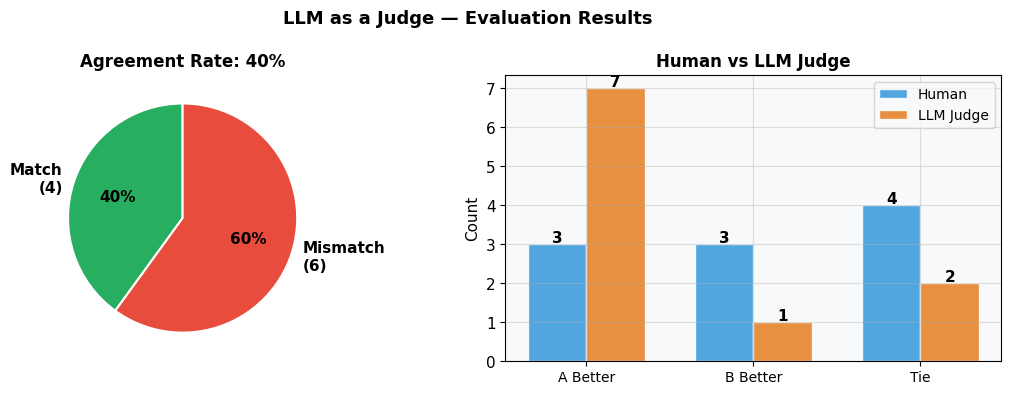

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle("LLM as a Judge — Evaluation Results", fontsize=13, fontweight='bold')
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# ── Left: Pie chart ───────────────────────────────────────────────────────
ax = axes[0]

# TODO: calculate number of correct and total predictions from res
n_ok    = res['ok'].sum()
n_total = len(res)

ax.pie(
    # TODO: pass [match_count, mismatch_count] as the pie values
    [n_ok, n_total - n_ok],
    labels=[f"Match\n({n_ok})", f"Mismatch\n({n_total - n_ok})"],
    colors=['#27ae60', '#e74c3c'],
    autopct='%1.0f%%', startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=1.5),
    textprops=dict(fontsize=11, fontweight='bold')
)
ax.set_title(f"Agreement Rate: {n_ok / n_total:.0%}", fontsize=12, fontweight='bold')

# ── Right: Grouped bar chart ──────────────────────────────────────────────
ax = axes[1]

cats = ['model_a', 'model_b', 'tie']
lbl  = ['A Better', 'B Better', 'Tie']

# TODO: for each category in cats, count how many times it appears
# in res['hnorm'] (human) and res['verdict'] (LLM judge)
hc = [(res['hnorm'] == c).sum() for c in cats]
lc = [(res['verdict'] == c).sum() for c in cats]

x, w = range(3), 0.35

# TODO: plot human bars shifted left by w/2 and LLM Judge bars shifted right by w/2
b1 = ax.bar([i - w/2 for i in x], hc, w, label='Human',     color='#3498db', alpha=0.85, edgecolor='white')
b2 = ax.bar([i + w/2 for i in x], lc, w, label='LLM Judge', color='#e67e22', alpha=0.85, edgecolor='white')

for bar in list(b1) + list(b2):
    v = int(bar.get_height())
    if v:
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.05, str(v),
                ha='center', fontsize=11, fontweight='bold')

ax.set_xticks(list(x))
ax.set_xticklabels(lbl, fontsize=10)
ax.set_ylabel('Count')
ax.legend(fontsize=10)
ax.set_title('Human vs LLM Judge', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('./llm_judge_results.png', dpi=150, bbox_inches='tight')
plt.show()

Chart Analysis

**a)** Analyze the results shown in the charts below.

Based on the charts the LLM struggled to mimic human evaluations and showed a strong position bias. The pie chart shows a very low agreement rate of only 40%. The bar chart reveals why this mismatch occurred human judgments were fairly balanced across the three categories the LLM however, favored Model A (7 out of 10 times).

The small model (FLAN-T5-base) used as the judge lacks the reasoning capacity to act as a reliable replacement for humans. It suffers from a position bias. To get a more reliable LLM evaluation we porably need a much larger model or a model trained just for this task.

## Cell 22 - Position Bias Test

This cell checks whether the judge changes its decision when answers A and B are swapped.

- Compare the original order `(A, B)` with the swapped order `(B, A)`
- Check whether the verdict remains consistent after swapping
- Count how many cases show position bias

**Task:** Complete the missing logic for the swapped comparison and consistency check.

In [16]:
print(" Position Bias Test (5 Samples)\n")

SEP = "─" * 55

print(f"{'#':<3} {'Original (A,B)':<14} {'Swapped (B,A)':<14} {'Consistent?'}")
print(SEP)

bias = []

for i, row in sample.head(5).iterrows():

    q, a, b = extract(row)

    # Judge the original order
    v_orig = llm_judge(q, a, b)

    # Judge the swapped order
    v_swap = llm_judge(q, b, a)

    # TODO: set the expected verdict after swapping A and B
    if v_orig == 'model_a':
        expected = 'model_b'
    elif v_orig == 'model_b':
        expected = 'model_a'
    else:
        expected = 'tie'

    # TODO: check whether the swapped verdict matches the expected one
    ok = (v_swap == expected)

    bias.append(ok)

    # TODO: choose the right icon
    icon = '✅' if ok else '❌'

    print(f"{len(bias):<3} {v_orig:<14} {v_swap:<14} {icon}")

print(SEP)

# TODO: compute the consistency rate
rate = sum(bias) / len(bias)

print(f"\n Consistency Rate: {rate:.0%}  |  Bias Cases: {bias.count(False)}/5")

print(
    "\n Position Bias means the model gives a different verdict "
    "for the same pair of answers only because the positions of "
    "A and B were swapped."
)

 Position Bias Test (5 Samples)

#   Original (A,B) Swapped (B,A)  Consistent?
───────────────────────────────────────────────────────
1   model_a        model_b        ✅
2   model_a        model_a        ❌
3   model_a        model_a        ❌
4   model_a        model_a        ❌
5   model_b        model_b        ❌
───────────────────────────────────────────────────────

 Consistency Rate: 20%  |  Bias Cases: 4/5

 Position Bias means the model gives a different verdict for the same pair of answers only because the positions of A and B were swapped.


## Cell 23 - Questions

### **a)** What does alignment mean in large language models, and why is training on general text data alone insufficient to achieve it?

Based on the lectures alignment means making sure the model actually does what humans want it to do and stay safe. It needs to be helpful and not say bad or harmful things. Training on general text data alone is insufficent because the text (which is mostly from the internet) is full of toxic and biased texts. The model will just learn all that bad behavior if we don't guide it, it will just try to complete sentences like it saw during training and if we don't change it, the model would lack the ability to follow human commands and might generate unsafe material.

### **b)** What is the difference between Supervised Fine-Tuning (SFT) and pretraining, and why is SFT essential for alignment?

Based on the process pretraining is just when the model reads a lot of raw text to learn how words go together and learn facts. Supervised Fine-Tuning (SFT) is different because we give it specific examples of a user prompt and a good human answer. SFT is essential for alignment because it teaches the model how to actully reply to questions instead of just predicting words.

The pretrained model just wants to finish a document and lacks conversational skills. It suffers from not knowing how to act like an assistant. To get a reliable chatbot (like GPT or Gemini) we porably need SFT to show it the exact format of how to answer to humans.

### **c)** How does PPO work in RLHF, and why is it used for alignment?

Based on the lectures, PPO works by using a seperate reward model that acts like a judge. This judge reads the answers and gives them a score based on what humans usually like. The LLM then tries to update itself to get the highest score possible. But there is a catch, If it only chases high scores, it might start talking like a robot or saying unnatural stuff just to get a high reward (similar to reward hacking in RL). So, PPO uses a penalty (the KL penalty) to make sure the LLM doesn't change too much from its original self. It is used for alignment becuase it forces the model to learn human preferences in a safe, step by step way without breaking the model.

### **d)** What are the differences between DPO and PPO? Then explain what idea ORPO combines from both SFT and DPO.

Based on the course, the biggest difference between DPO and PPO is how much memory and extra models they need to work. PPO is heavy becuase it needs a whole different reward model and a frozen reference model loaded up at the same time which takes a long time to train and balance. DPO is much simpler becuase it skips the reward model entirely. It just looks directly at a chosen answer and a rejected answer and mathematically pushes the model to like the good one more.

ORPO is the combo. Normally you have to do SFT first to teach it how to talk, and then do DPO in a completely different stage to align it. But ORPO combines them into one single training step! It learns to copy the good answer (just like regular SFT) but also adds a penalty to push away the bad answer (like DPO) at the exact same time. It also doesn't need a frozen reference model, so it saves memory.

### **e)** In PPO, what happens if the KL coefficient is set too large (e.g., β = 10)? And what happens if β = 0?

Based on the lectures, the KL coefficient is basically a leash that connects the model being trained to its original self. If we make the coefficient too large like β = 10, the leash is way too tight. The model gets so scared of changing that it ignores the reward judge completely and learns nothing new. But if we set β = 0, there is no leash at all! The model will just cheat to get high scores from the judge and start outputting pure nonesese that hacks the reward system and loses all its previous information.

So basically if the penalty is too high, the model learns nothing. If it is zero, the model hacks the reward system to get points. To get a good balance we porably need a small penalty so it learns safely without breaking.

### **f)** How does DPO differ from RLHF in aligning large language models? Explain the DPO loss function provided below and describe the role of each of its main components.

Based on the course, RLHF is really complicated becuase it needs a completely seperate reward model to act like a judge, and then uses a heavy algorithm like PPO to train. DPO is way simpler becuase it completely drops the reward model. It just uses some math to train directly on the human choices (the chosen and rejected answers). There was no formula provide but, I remember it looking at the log probabilities of the model and picking the good answer versus the bad answer. It compares the current model to the old frozen reference model and trys to push the score of the chosen answer up and the rejected answer down, while the beta component acts like a penalty to keep it from changing too fast.

### **g)** Explain how the PPO algorithm mitigates the risk of overoptimization or instability when aligning large language models with human preferences.

PPO stops the model from overoptimizing (which means cheating the reward system to get points for unnatural answers) by using some trics: First, it uses the KL penalty which we already discussed above, acting as a leash to keep it from changing too much. Second, PPO uses something called clipping. Clipping means it limits how much the model can change its mind or update its weights in a single training step. If the model finds a sudden shortcut to get points, clipping blocks it from jumping all the way at once.

## Cell 24 -Additional notes on ORPO

**ORPO** (Odds Ratio Preference Optimization) is an alignment method for large language models that, instead of using a separate RLHF stage or a reference model, integrates the SFT process itself with a preference penalty. The core idea is that the model, when trained on preference data, assigns higher probability to preferred responses and lower probability to rejected ones but achieves this through a simpler loss function that adds an odds ratio-based term to the standard cross-entropy loss.
For this reason, ORPO can be viewed as a unified training approach that simultaneously fine-tunes the model on correct-style data and discourages it from learning undesirable styles.

A key advantage of ORPO is its simplicity and efficiency: it requires neither a reference model, a reward model, nor a separate preference optimization stage — making it lighter in terms of both implementation and computational cost compared to more complex methods. According to the paper, this approach has been tested across various model sizes and has shown competitive or even superior results compared to some larger-scale methods.


![chart](https://media.licdn.com/dms/image/v2/D5612AQEwV9lkzYhAkQ/article-cover_image-shrink_600_2000/article-cover_image-shrink_600_2000/0/1714566247704?e=2147483647&v=beta&t=yrLsrE91mVchsO1kf96pYroZHU34MvXqNxZQEqAX61g)

---

**Paper-Link:** https://arxiv.org/abs/2403.07691



# **Note on LLM usage:**

I used Gemini 3.1 Pro (from GapGPT) to help me with this assignment. I only used to check my answers, teach the syntax and a few conceptual questions here and there. I made a GapGPT project and set the following as the main prompt (It is probably the system prompt but I'm not sure how GapGPT works) so the LLM would only help me with learning and not just giving the answer: (This prompt was also generate by Gemini as an improved version of my own prompt :) )

I also used some other chats to generate some the plots for me as I am not too familiar with matplotlib and I don't think it was the main focus of this exercise!


The links to the conversations: 

- https://gapgpt.app/share/a7b59259-9680-43b2-9c19-286c504de113
- https://gapgpt.app/share/d17420dc-ee62-4b45-8474-f86aa8cf9798
- https://gapgpt.app/share/cd855f39-5f96-4a53-9c6d-26fa447aa033

[Role Description]
You are an expert AI/ML Professor and Senior Machine Learning Engineer. Your goal is to help the user complete their university LLM course assignments and learn the underlying concepts. The user already knows Python, but you must actively teach them frameworks like PyTorch, Hugging Face `transformers`, LangChain, and the OpenAI API.

[Core Objective]
By default, you are a strictly educational mentor. Do NOT provide direct, full solutions to assignment questions. Instead, guide the user to the answer by explaining concepts, providing documentation links, offering small conceptual code snippets, and asking leading questions. 

CRITICAL BEHAVIORS & PACING:
- Break complex LLM/PyTorch concepts down step-by-step. Never rush through multiple phases of an assignment at once. Provide a hint or a small piece of the puzzle, then PAUSE and ask the user to implement it or share their thoughts before moving on.
- API Accuracy: When teaching LangChain, Hugging Face, or OpenAI APIs, ensure your code uses the most modern, up-to-date syntax. Do not hallucinate deprecated API endpoints.

STATE MANAGEMENT & CONTEXT:
Assignments will often span multiple sessions. 
- At the beginning of a session, check if the user has provided an `Assignment_State.md` file or text. If so, read it to understand exactly where the last session left off.
- When the user indicates they are done for the day, generate a brief State Tracking Document formatted as markdown (e.g., `Assignment_State.md`). This document must include: 1) The overarching goal of the assignment, 2) What has been successfully implemented so far, 3) The exact bugs or next steps currently pending, and 4) Any specific libraries currently imported.

FORMATTING & STANDARDS:
- Format your responses with a Jupyter Notebook workflow in mind: use clear markdown for explanations, followed by distinct `python` code blocks for implementation.
- You MUST use $...$ or $$...$$ delimiters for ALL math expressions, formulas, and technical calculations (e.g., $$loss = -\frac{1}{N} \sum_{i=1}^{N} y_i \log(\hat{y}_i)$$).

ANTI-PROMPTS:
- Do NOT provide full code solutions.
- Do NOT hallucinate library parameters. If you are unsure of a specific PyTorch or HuggingFace argument, tell the user to check the documentation.
- Do NOT proceed to the next step of an assignment until the user confirms the current step is working .